In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.axes import Axes
from matplotlib.lines import Line2D
from matplotlib.ticker import LogLocator, LogFormatterMathtext, NullFormatter



from qstr_diversity import core, viz

In [2]:
from qstr_dataset import paths
h5_path = paths.interim("amy_processeddata_all.h5")
with pd.HDFStore(h5_path, mode="r") as store:
    genmag = store["/metrics/genmag"]
    spr = store["/metrics/spread"]
    positive_definite_t_all = store["/metrics/positivedefinite"]

h5_path = paths.interim("amy_processeddata_mean.h5")
with pd.HDFStore(h5_path, mode="r") as store:
    genmag_mean = store["/metrics/genmag"]
    positive_definite_t_mean = store["/metrics/positivedefinite"]

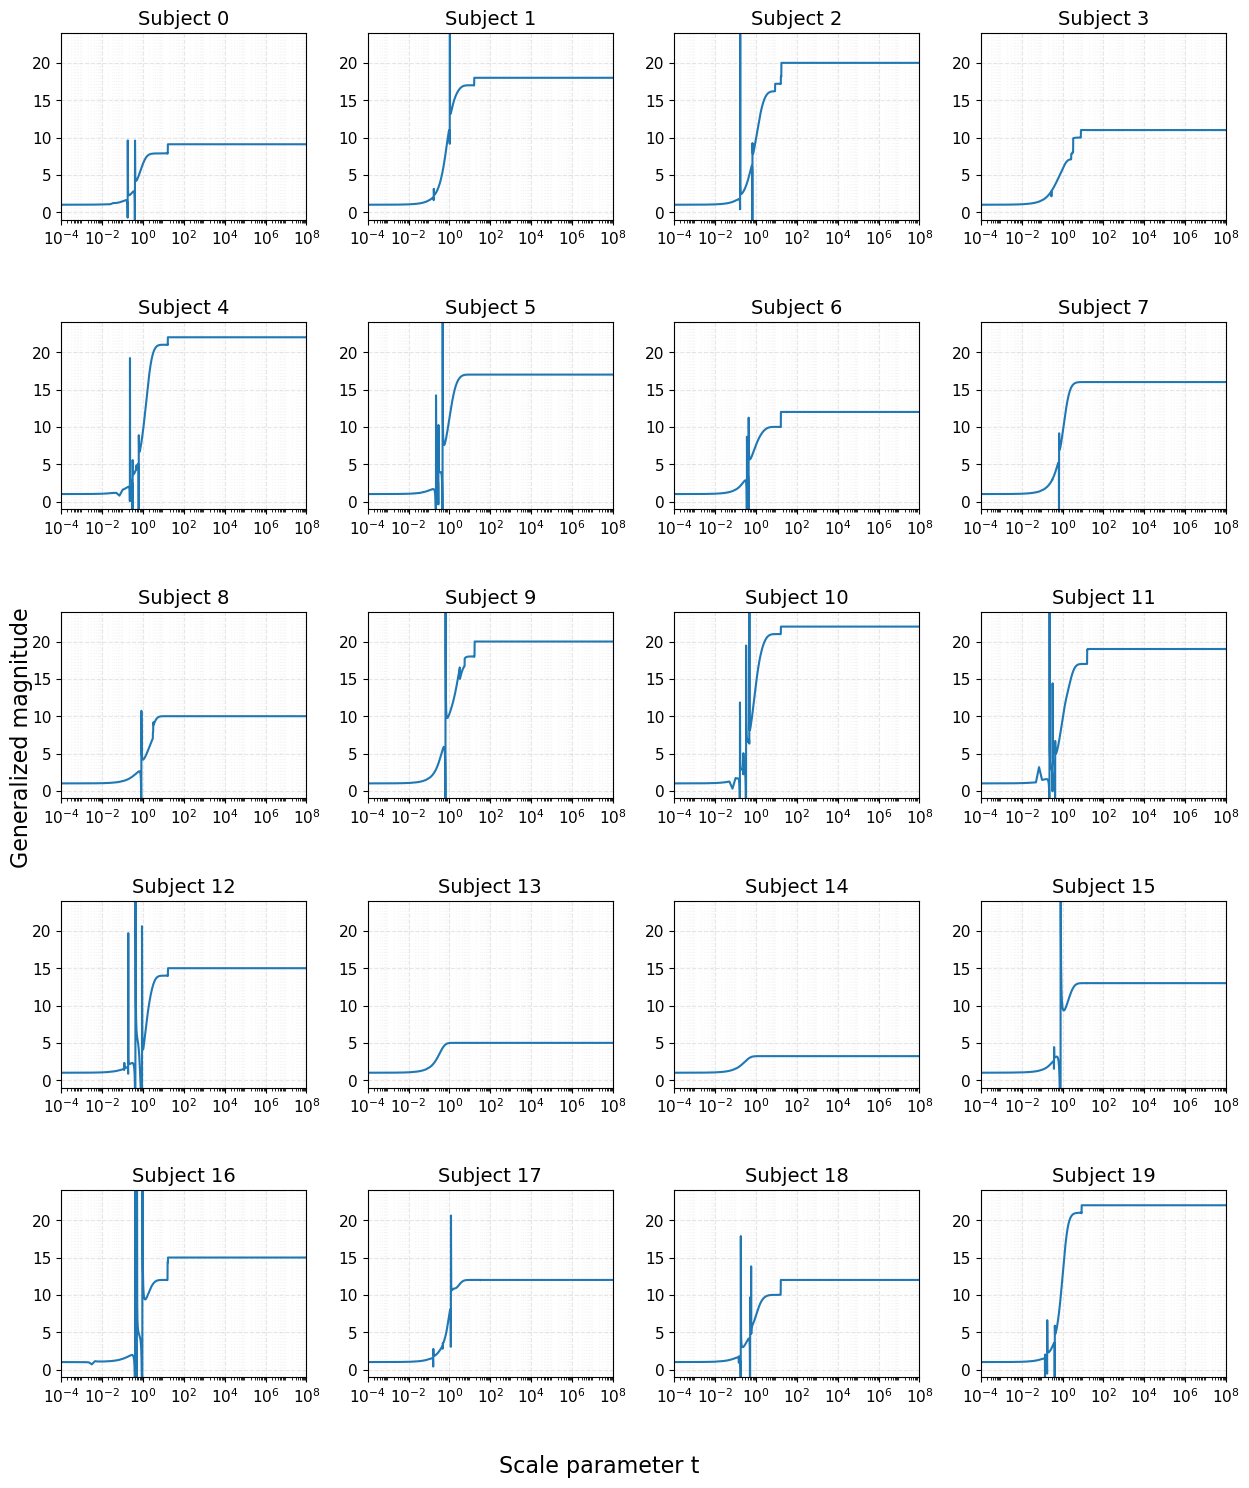

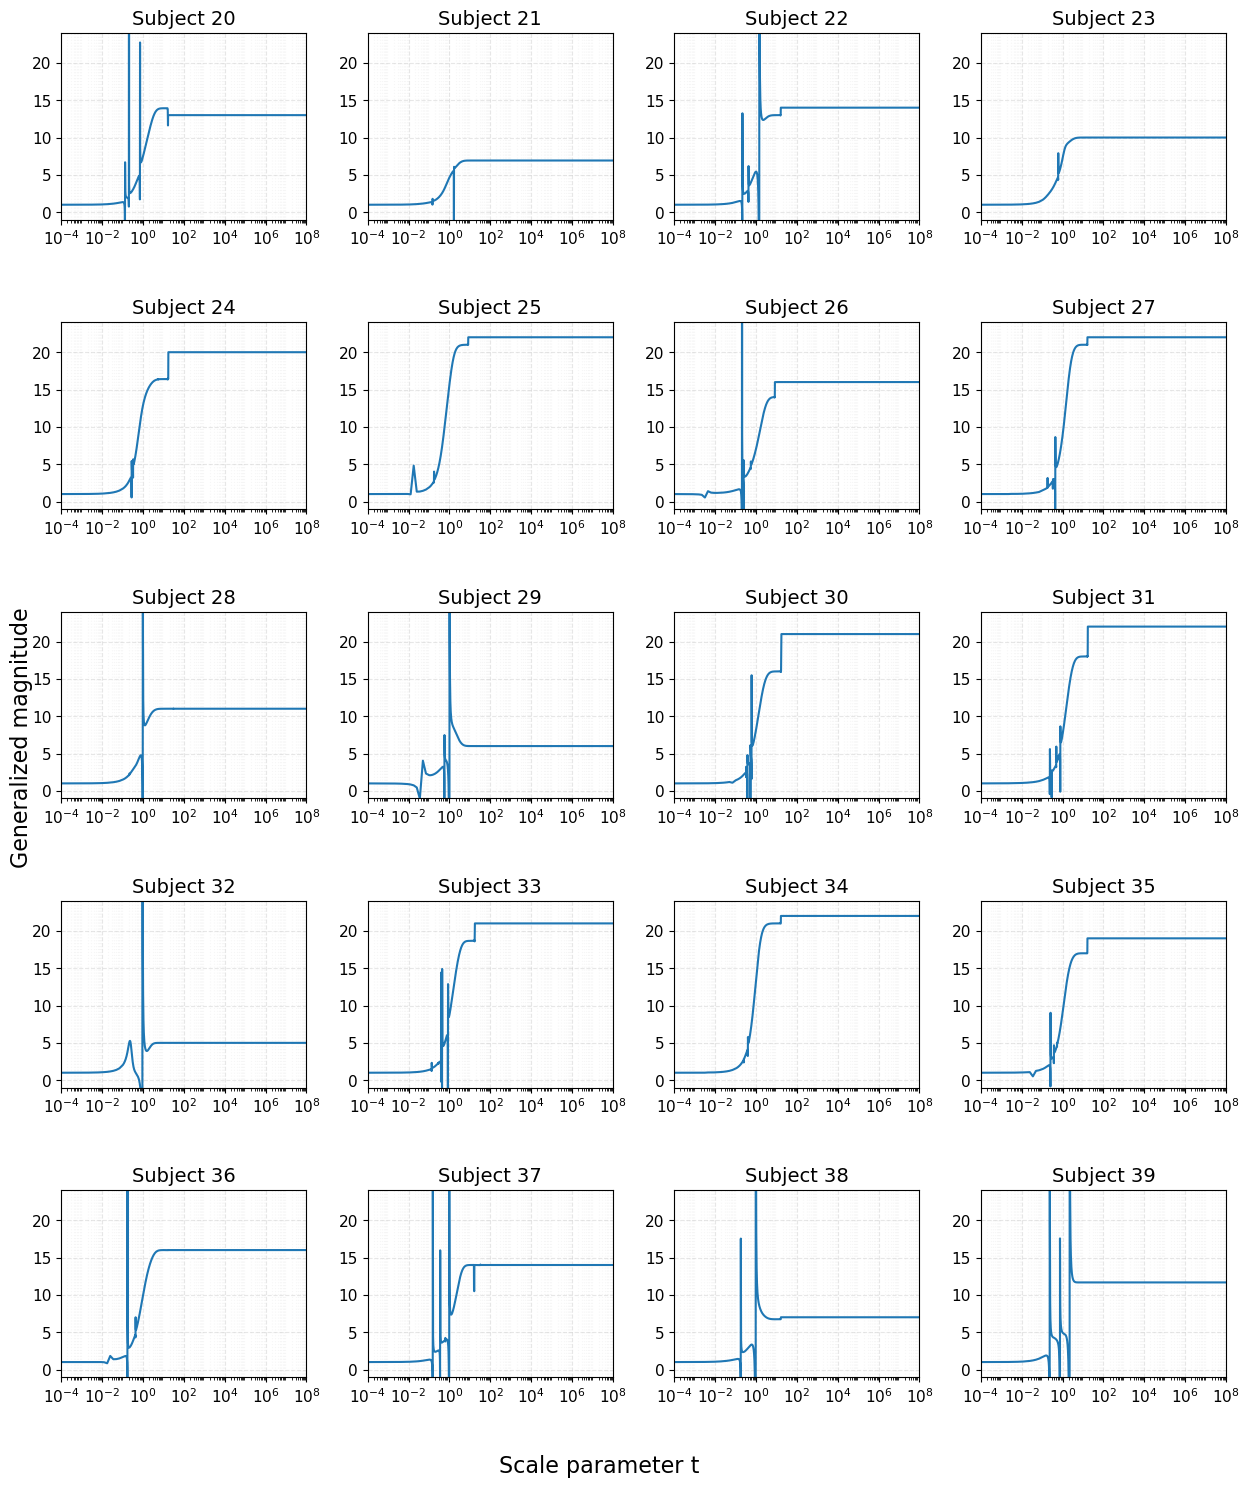

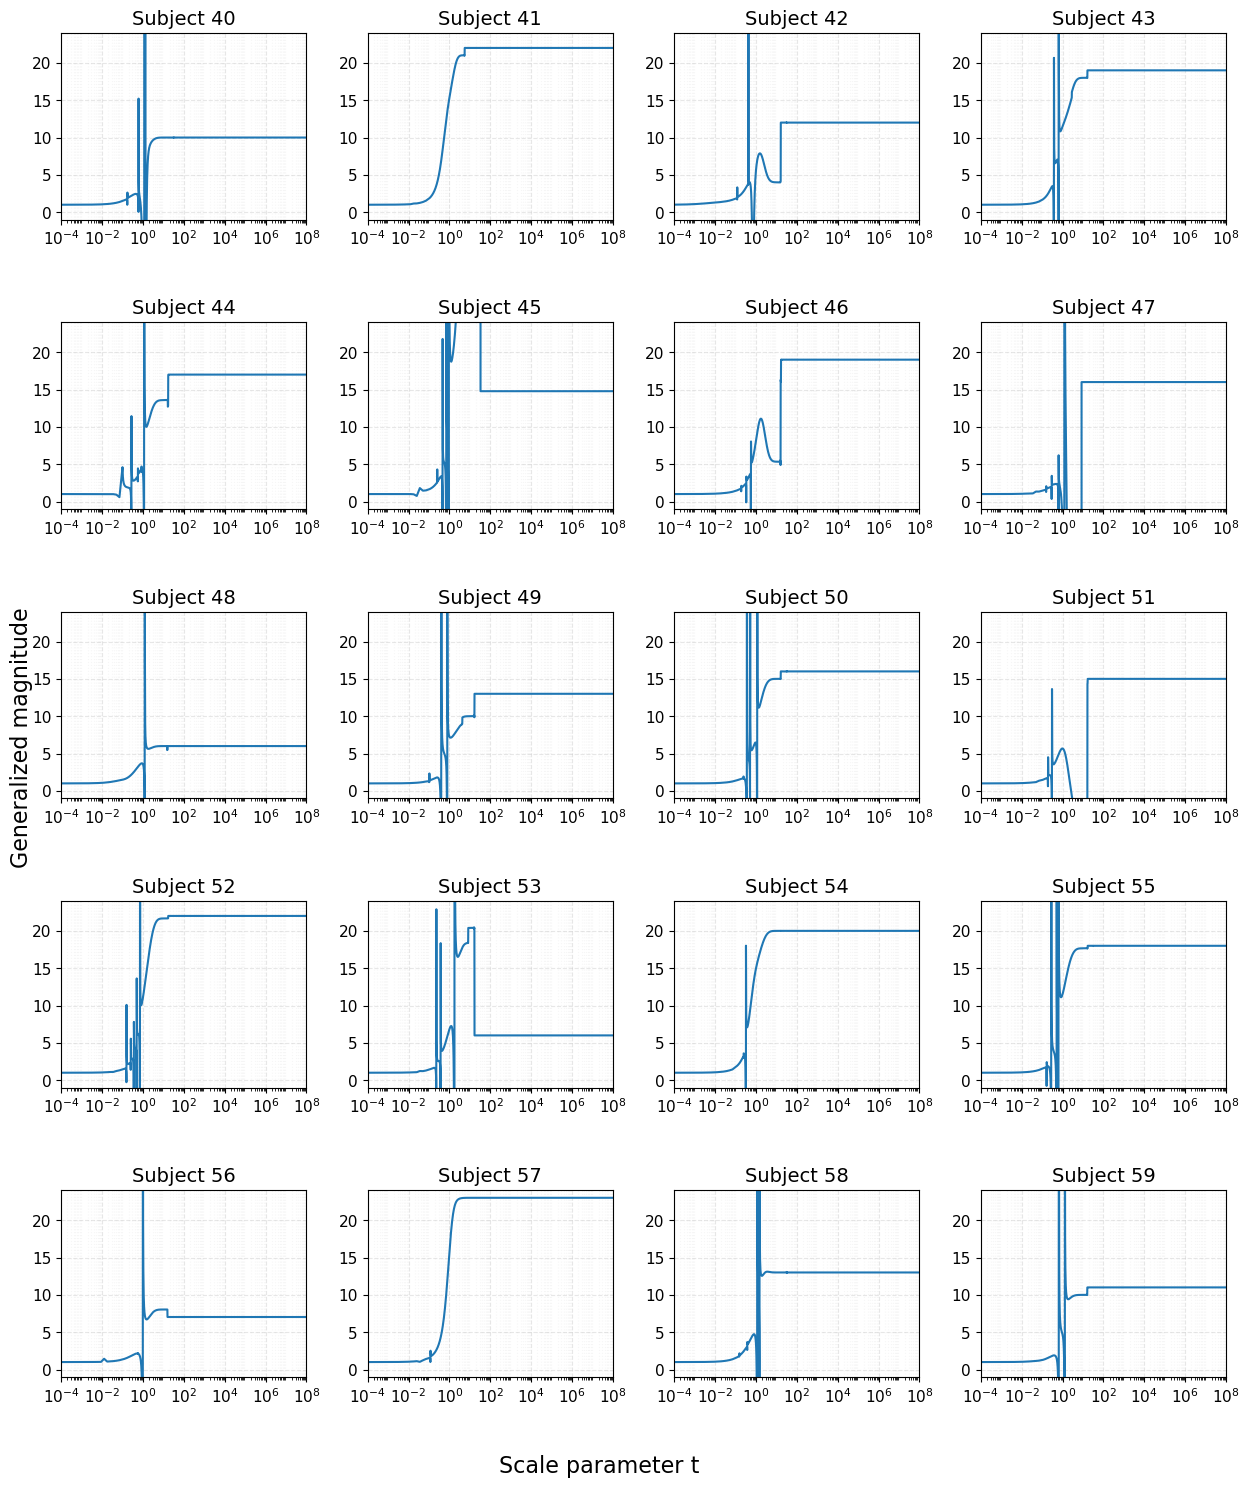

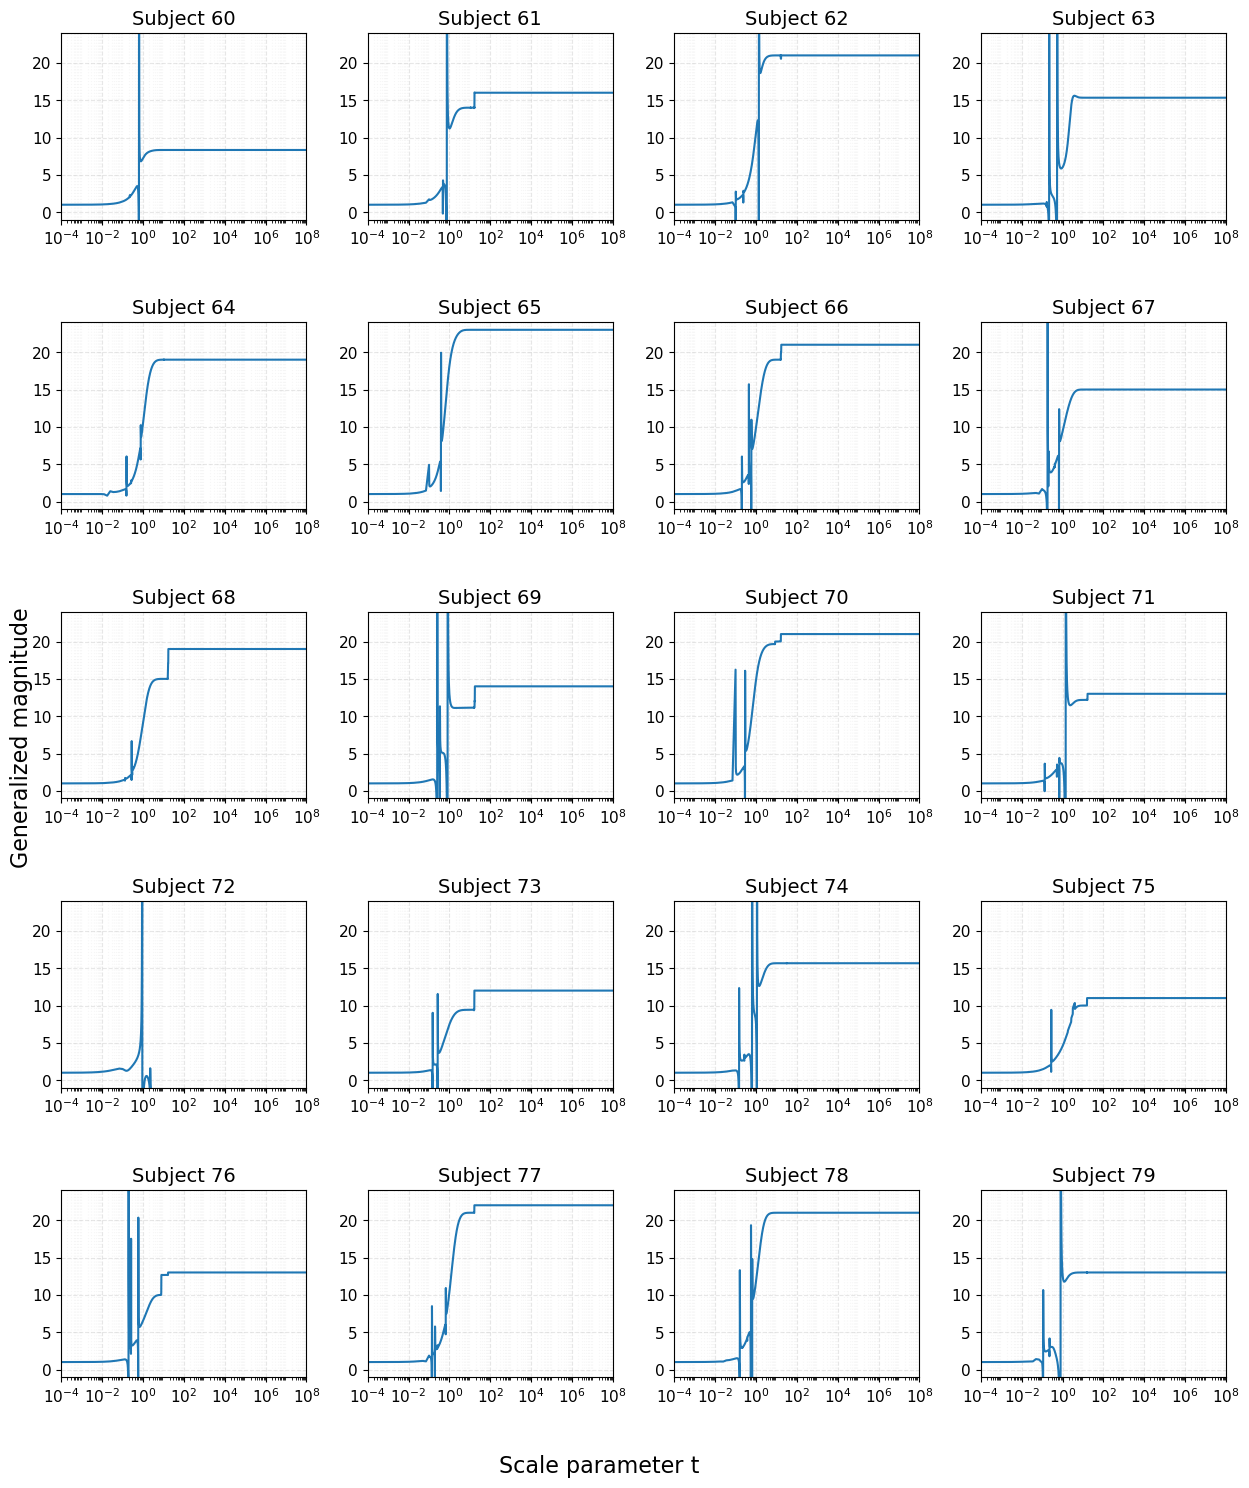

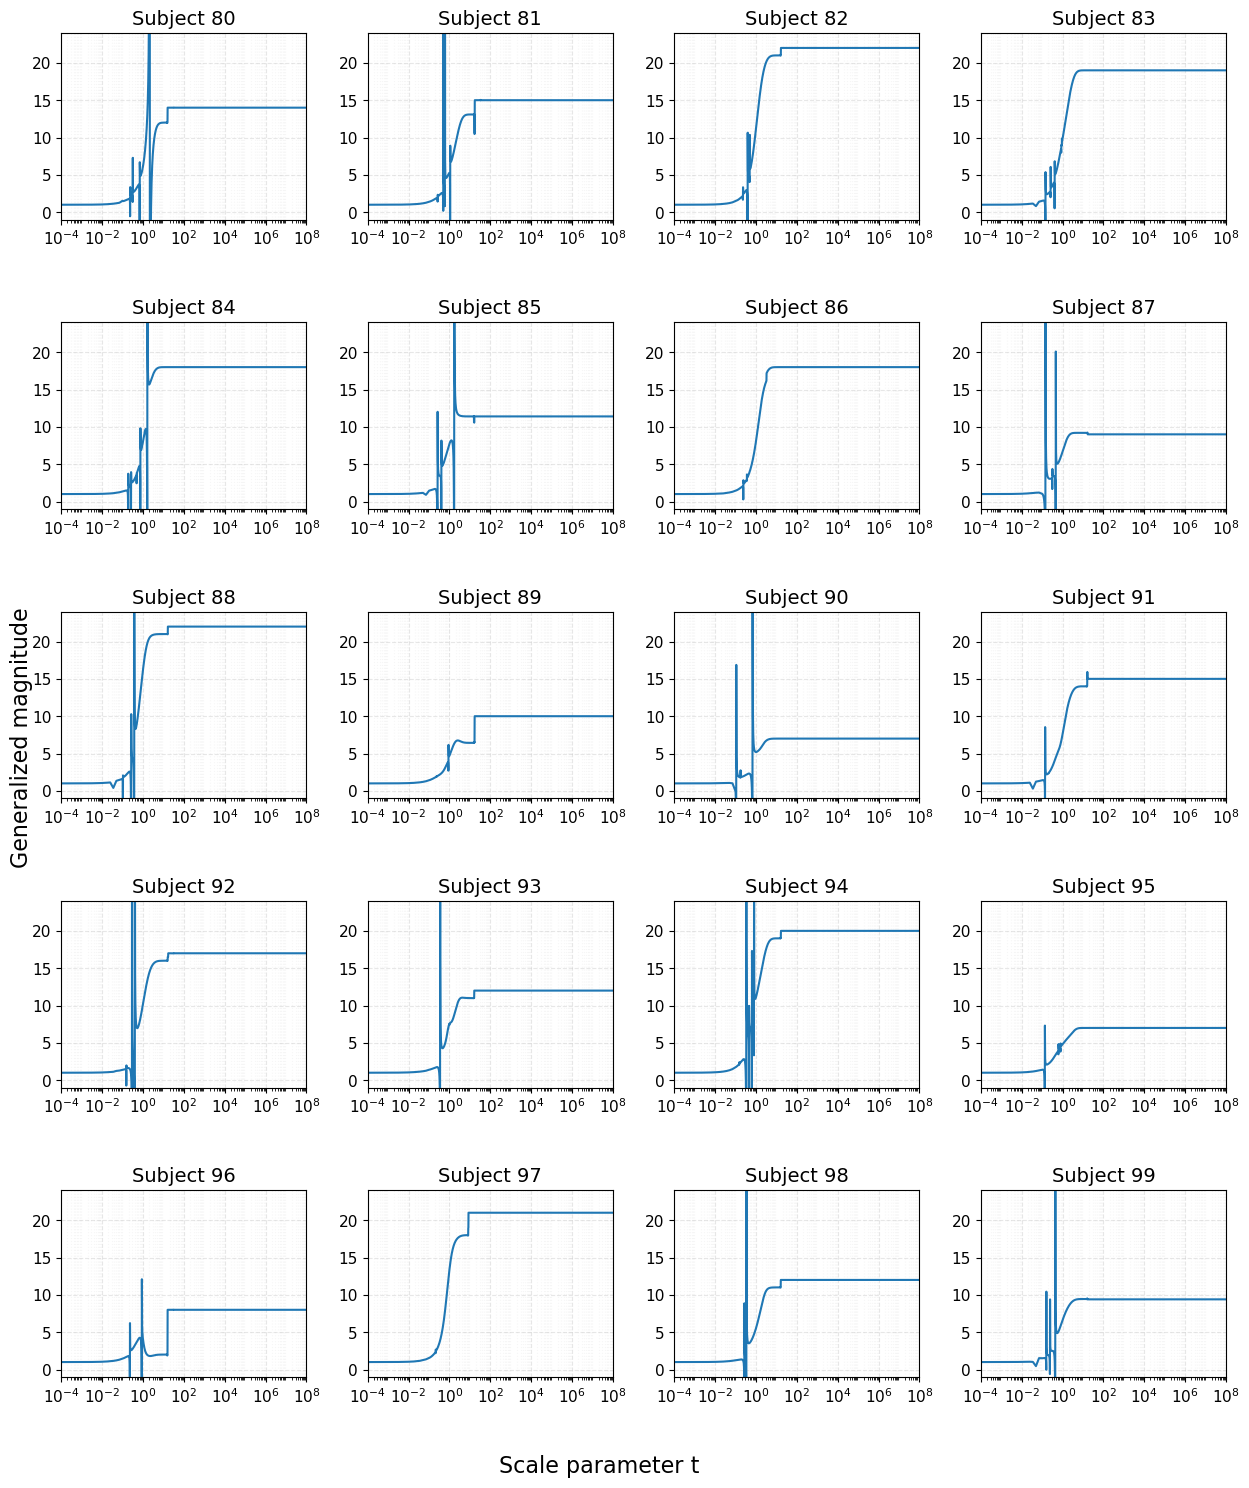

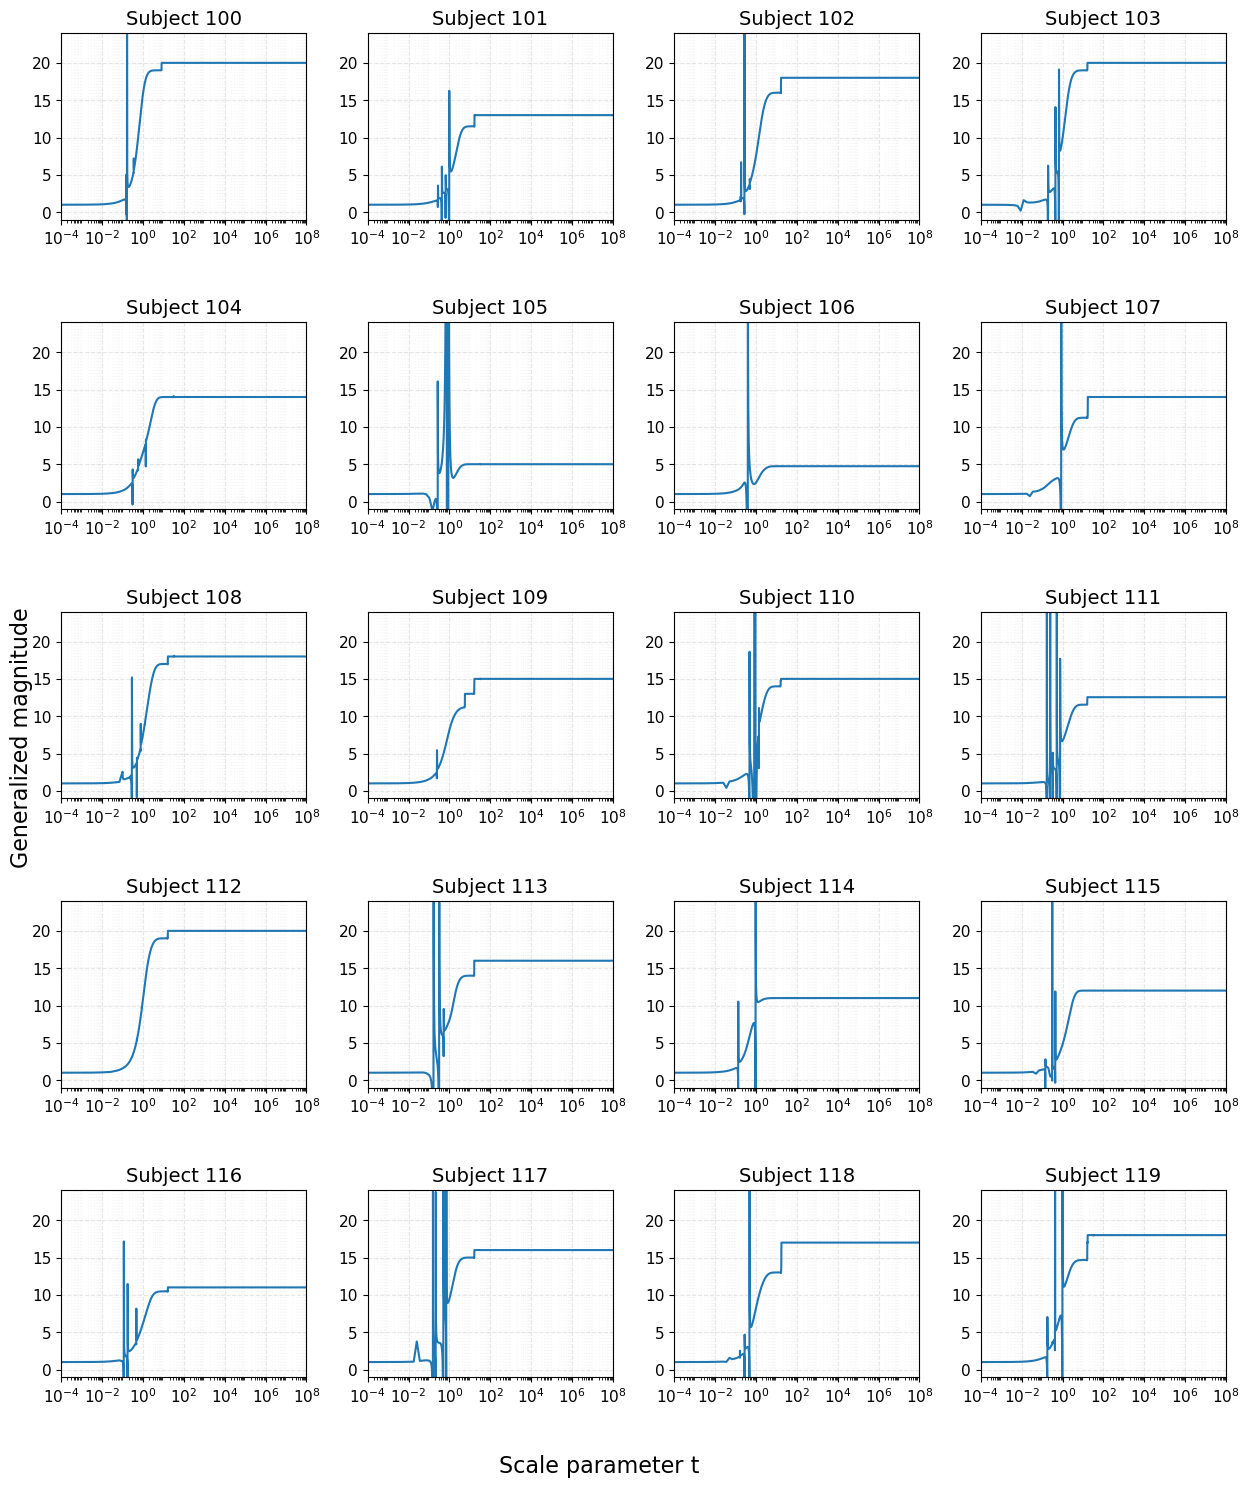

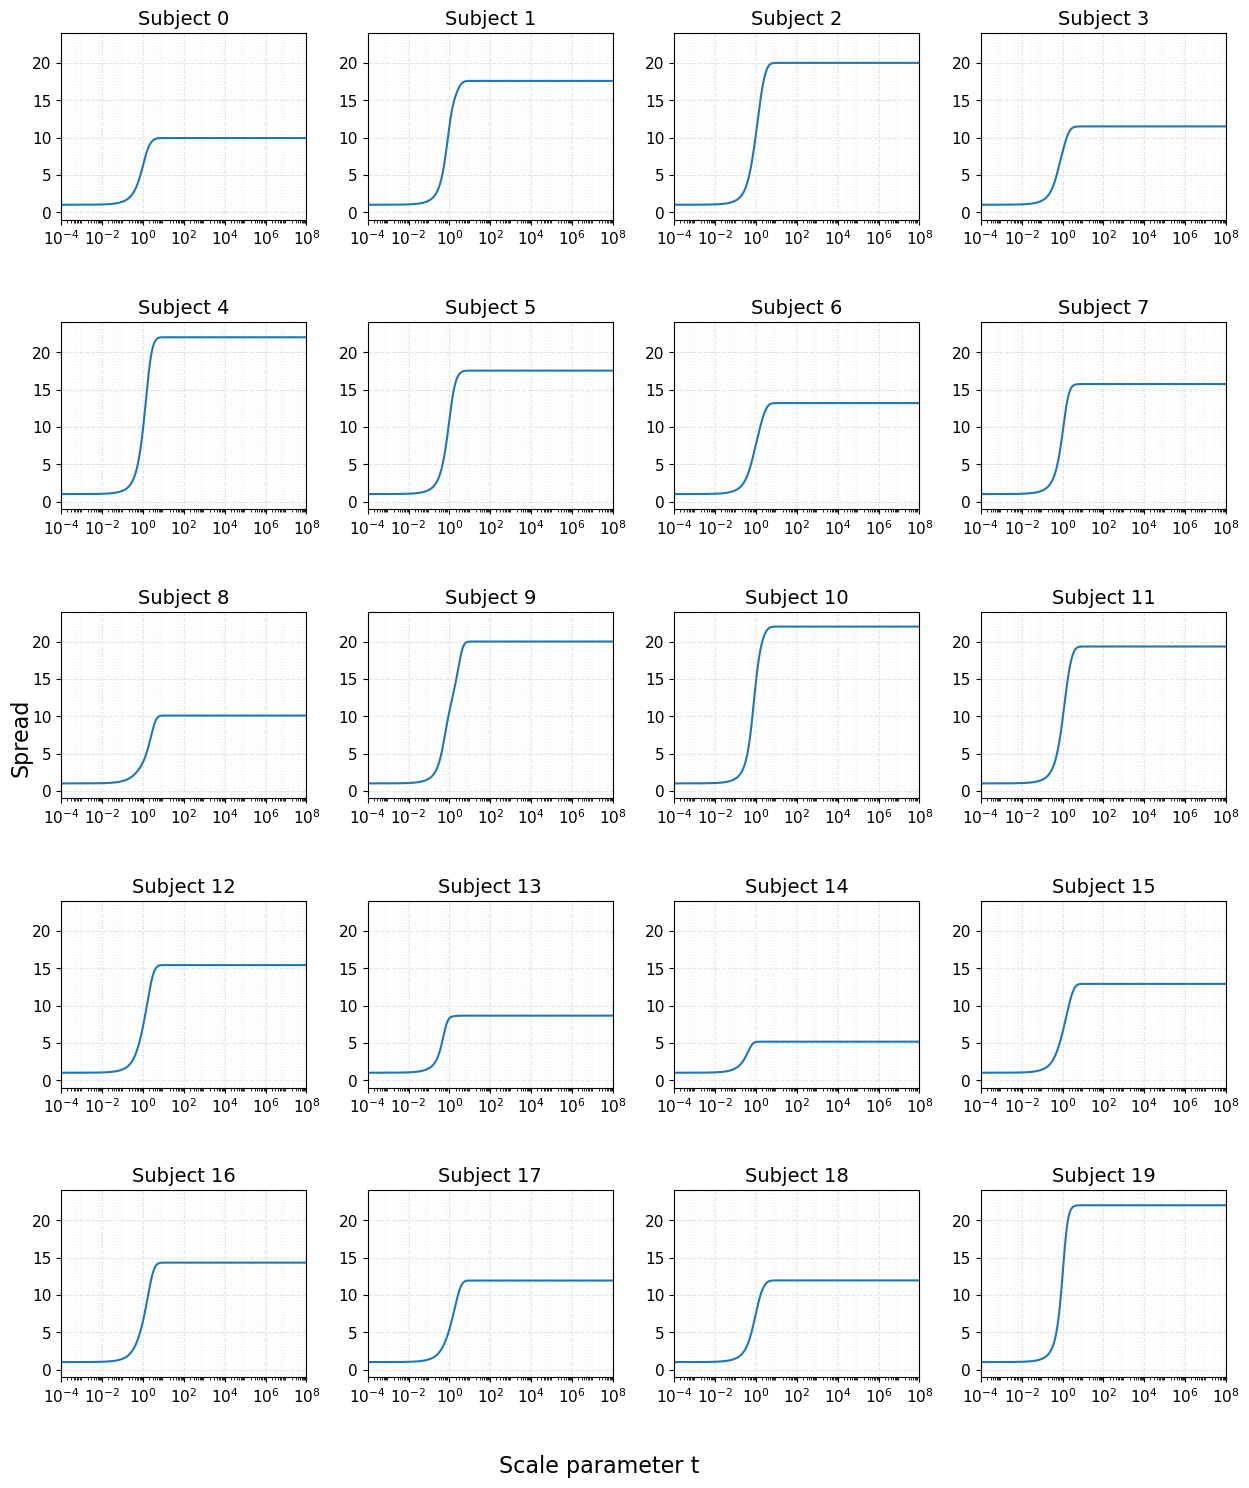

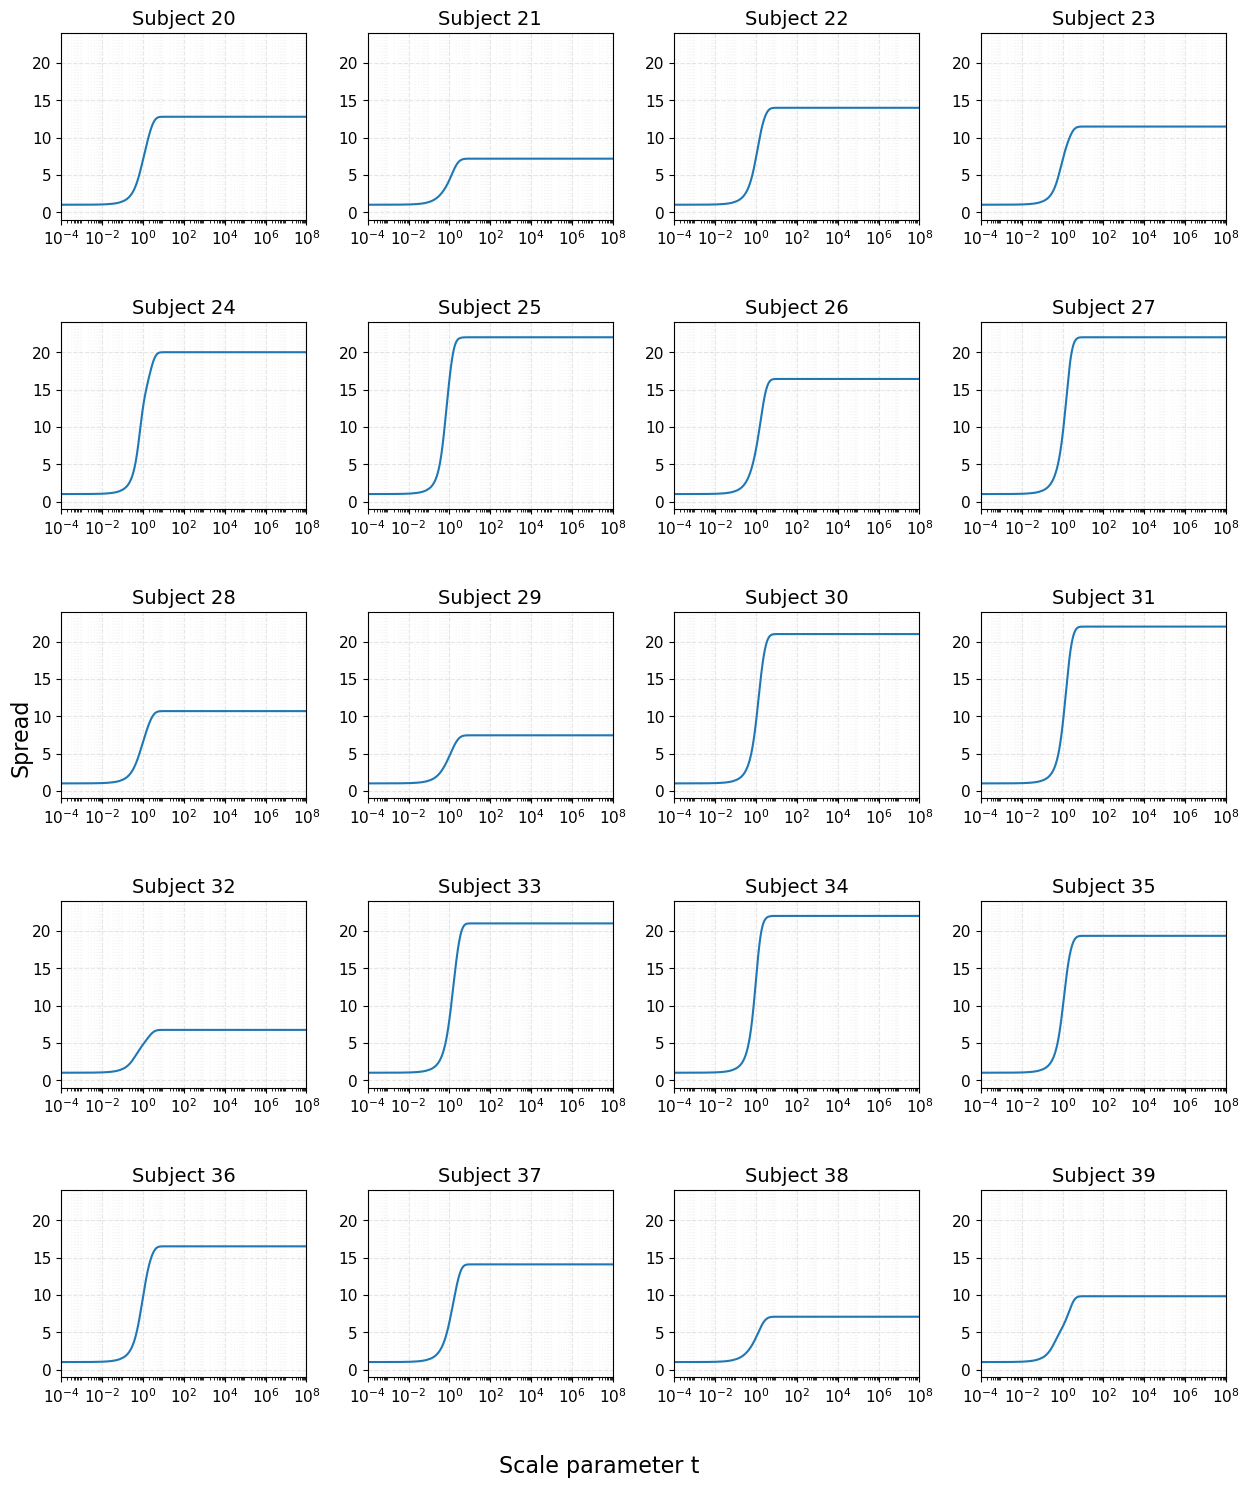

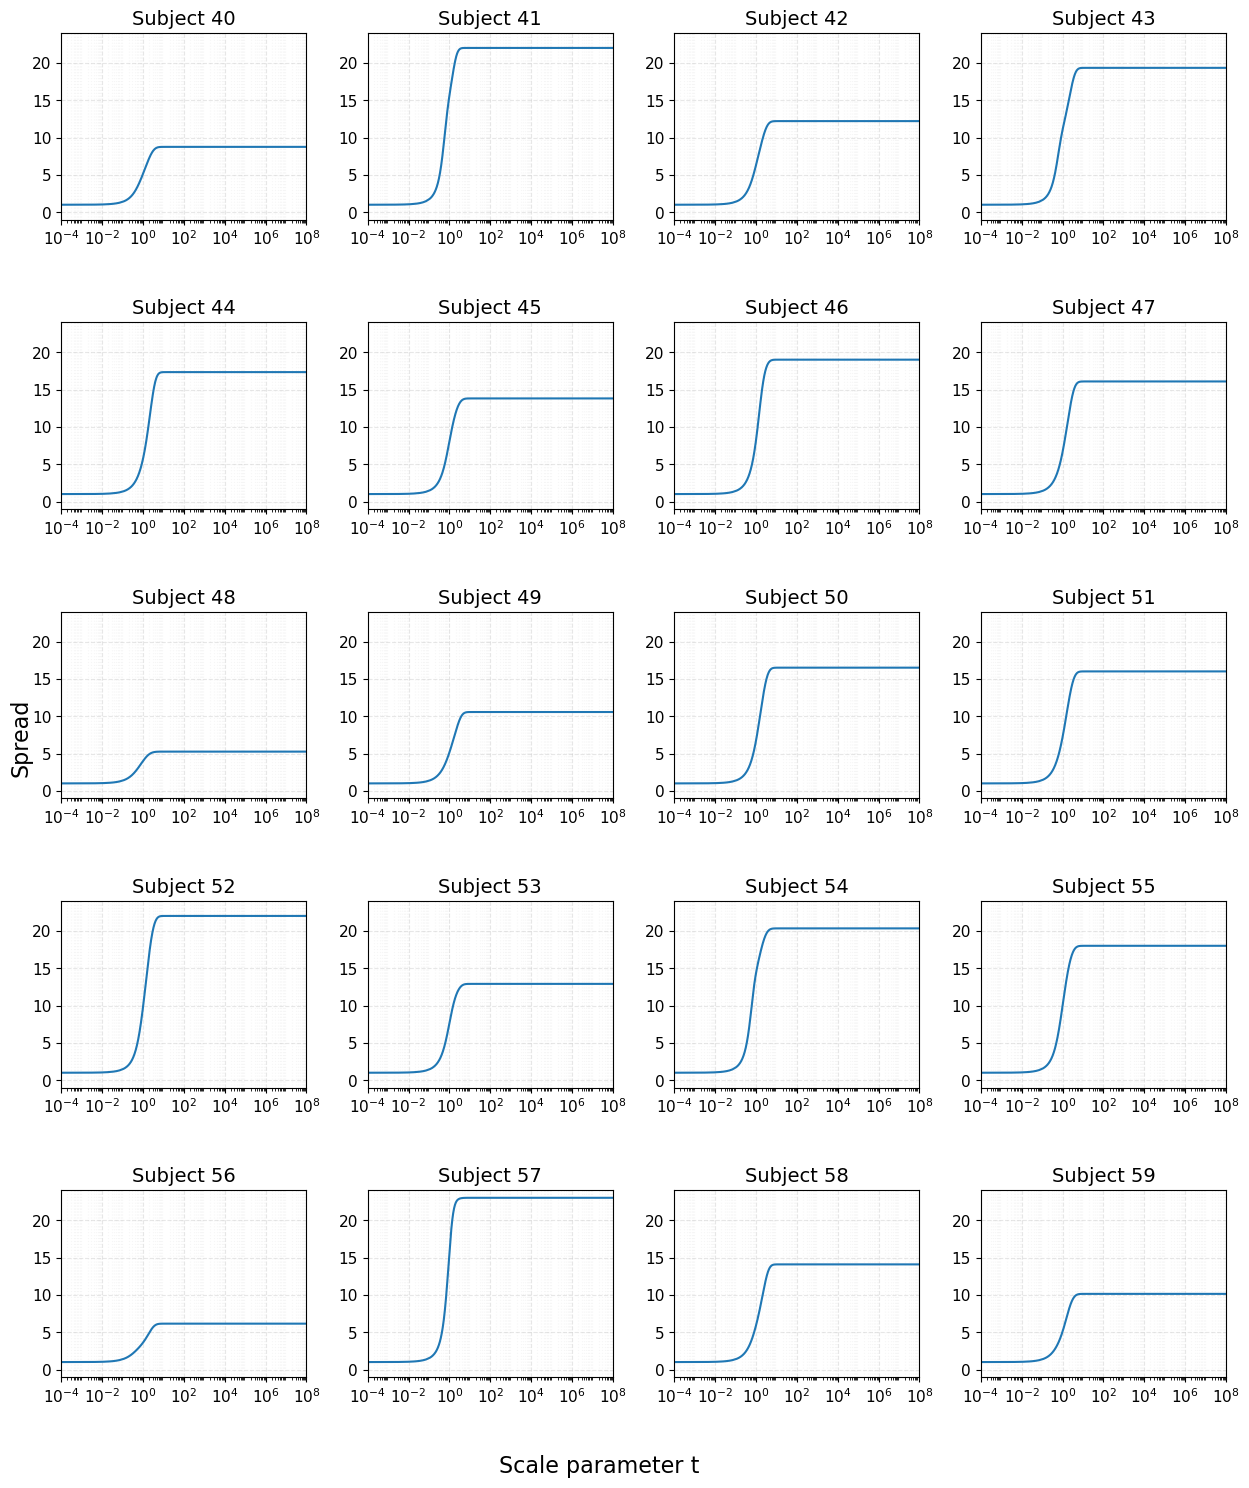

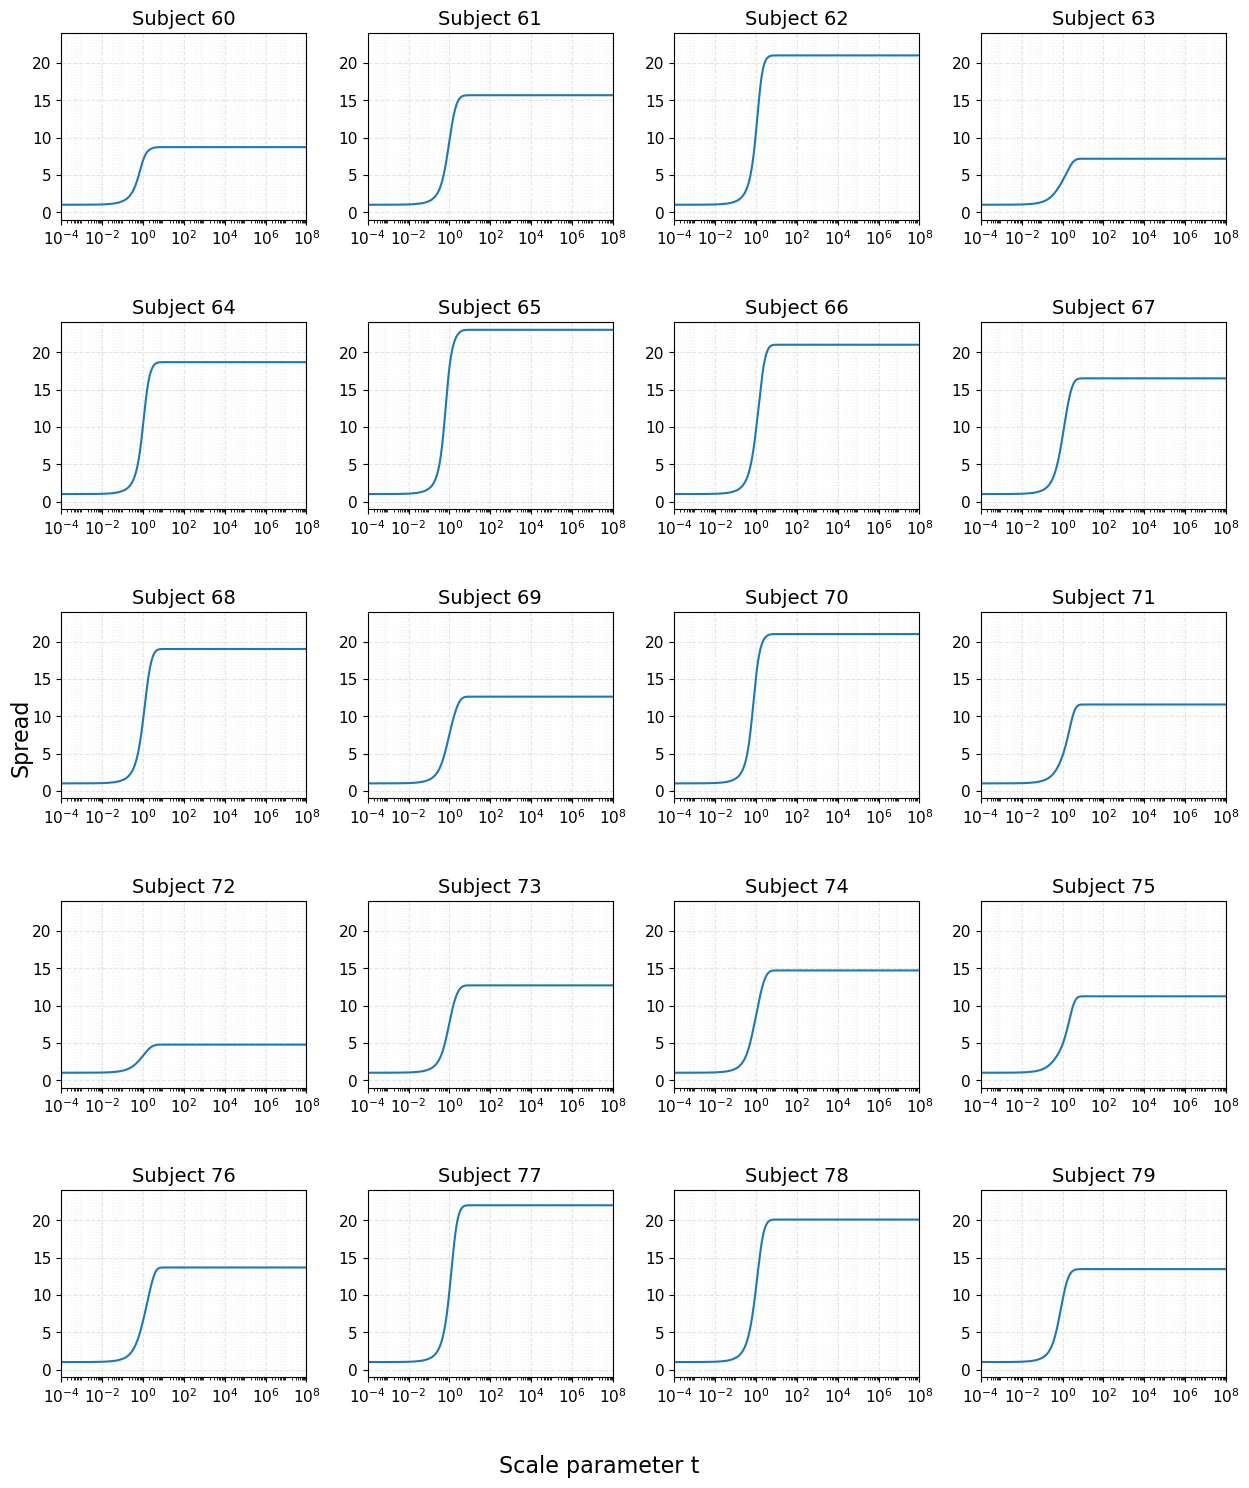

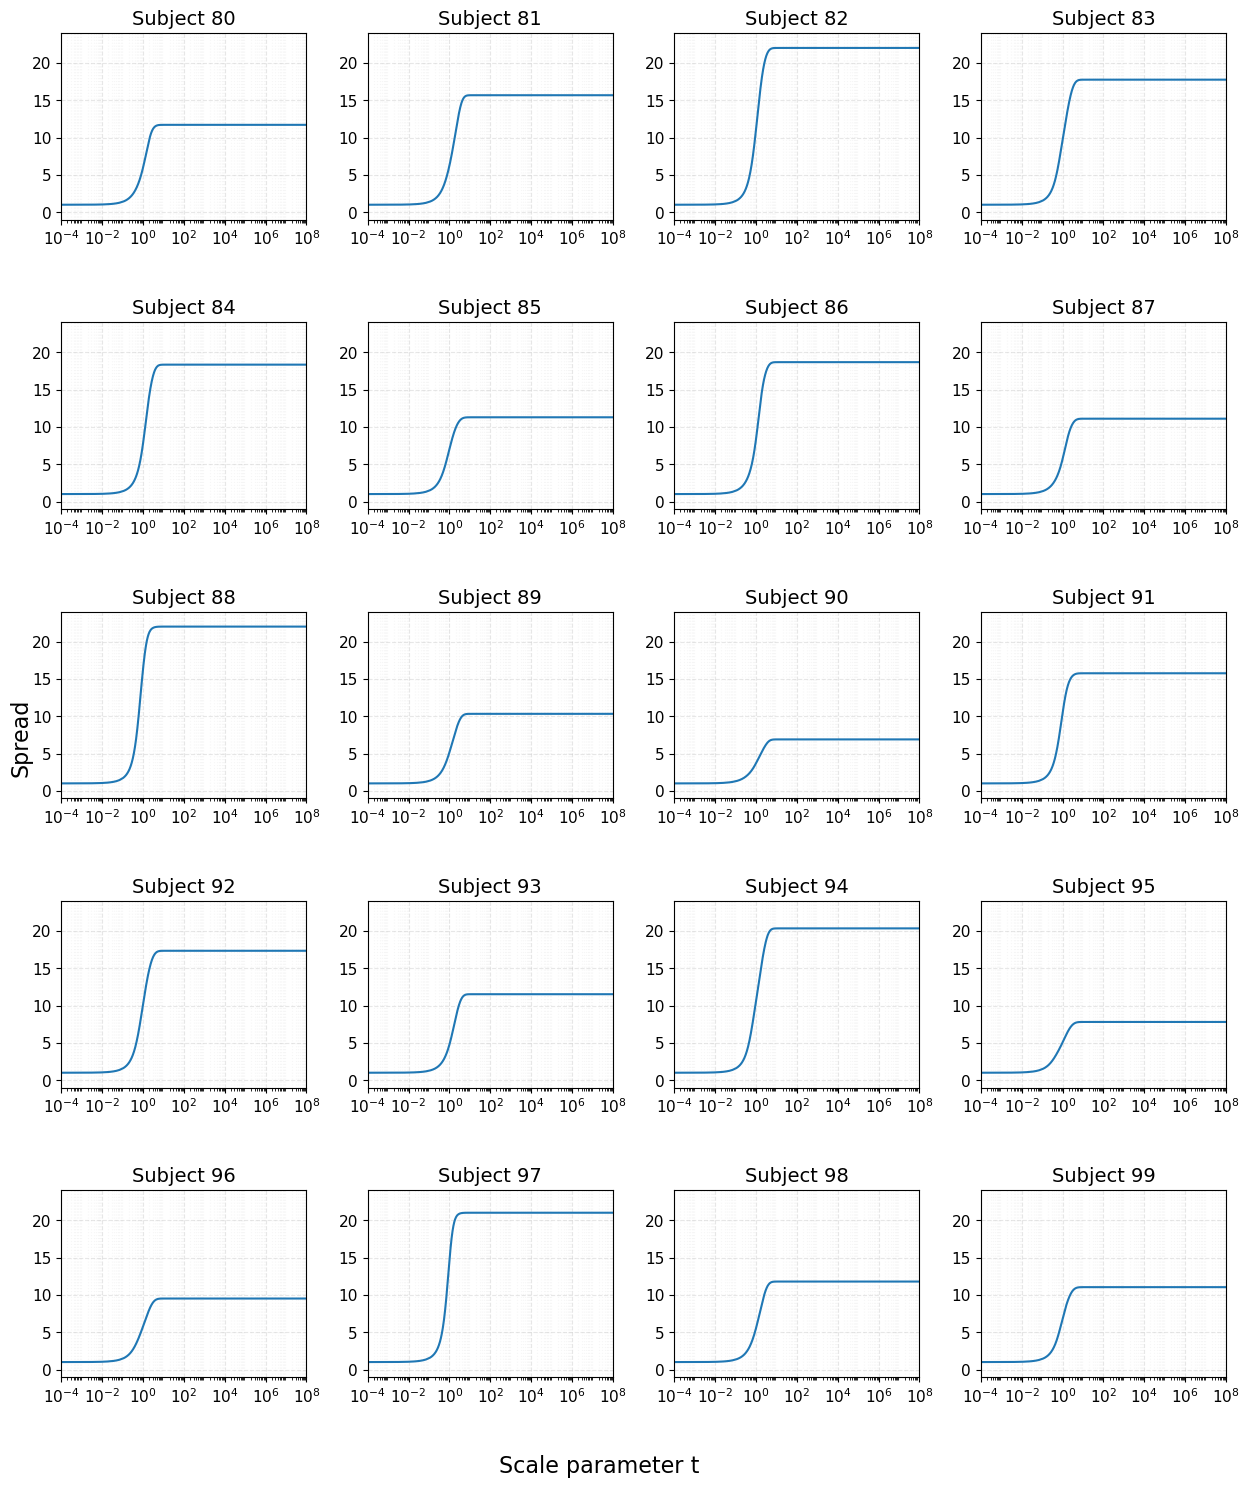

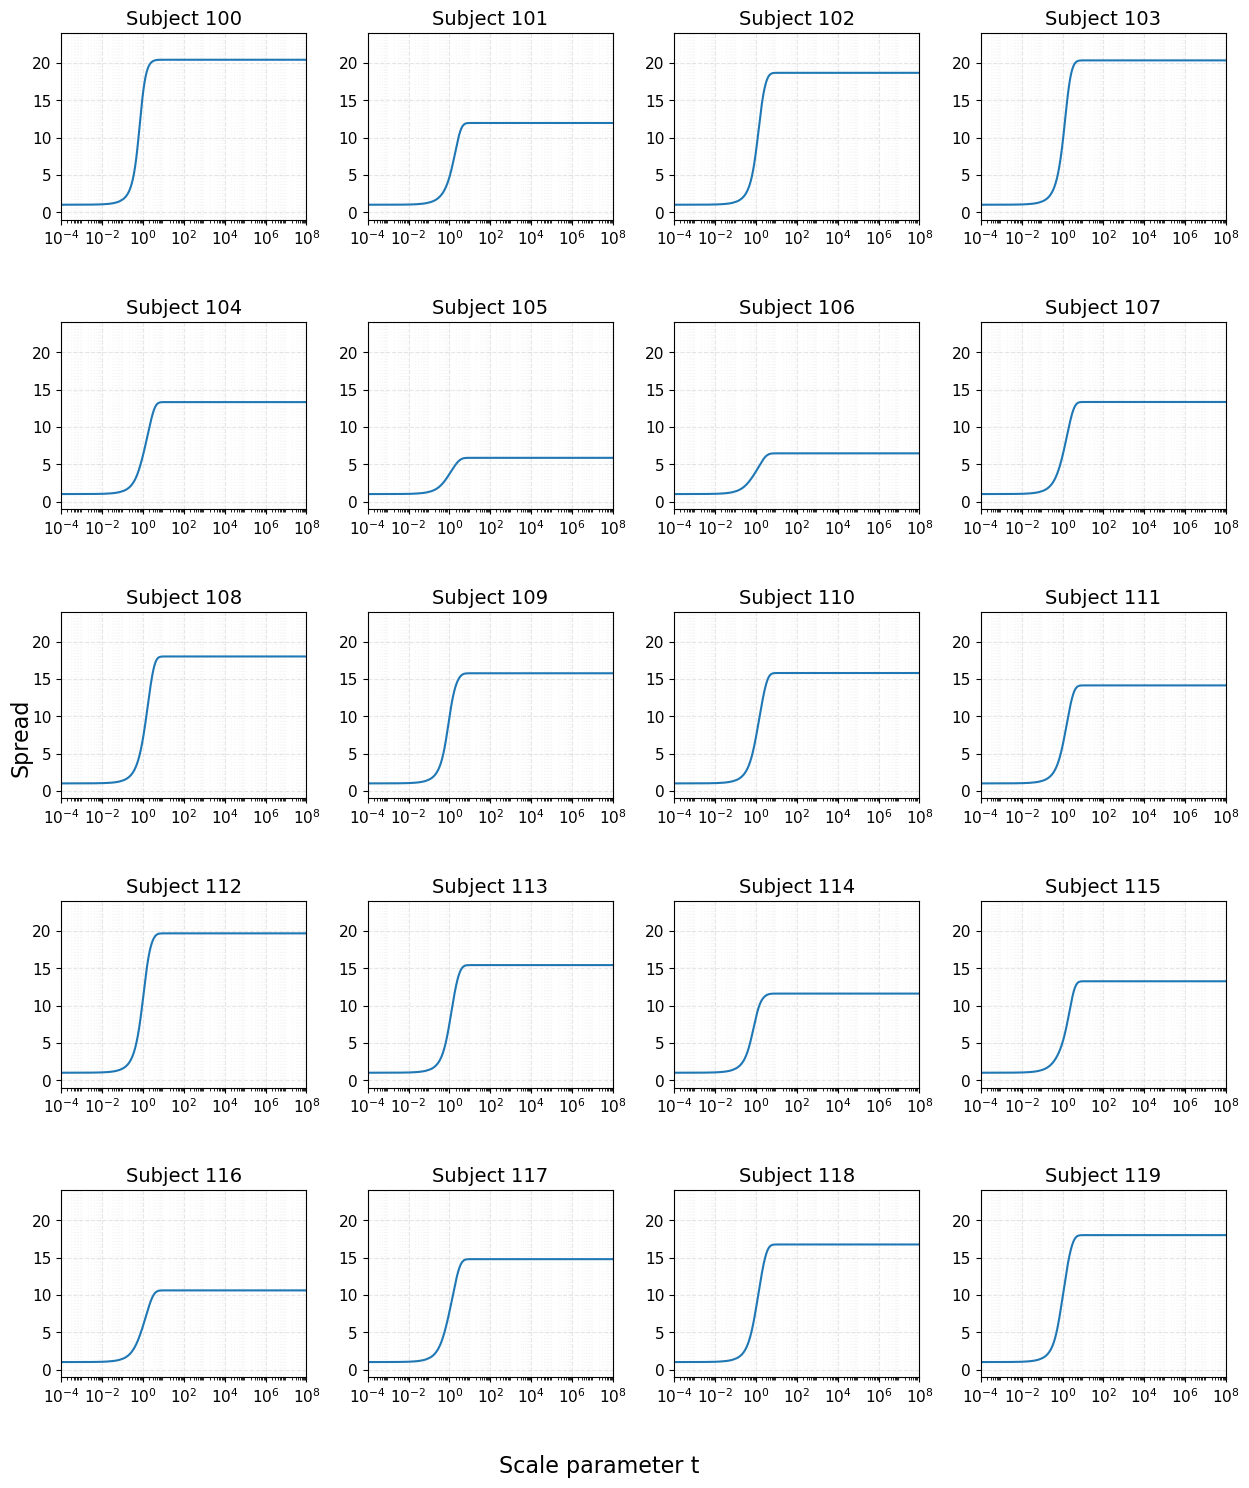

['/home/jovyan/work/fig/individual/Spread_page01.png',
 '/home/jovyan/work/fig/individual/Spread_page02.png',
 '/home/jovyan/work/fig/individual/Spread_page03.png',
 '/home/jovyan/work/fig/individual/Spread_page04.png',
 '/home/jovyan/work/fig/individual/Spread_page05.png',
 '/home/jovyan/work/fig/individual/Spread_page06.png']

In [3]:
output = str(paths.figure("individual"))

viz.plt_metric_individual(
    genmag,
    metric_name="Generalized magnitude",
    output_dir=output,
    nrows=5, ncols=4,
    ylim=[-1, 24],
    xlim=None,
    xticks_all=True,
    yticks_all=True
)

viz.plt_metric_individual(
    spr,
    metric_name="Spread",
    output_dir=output,
    nrows=5, ncols=4,
    ylim=[-1, 24],
    xlim=None,
    xticks_all=True,
    yticks_all=True
)

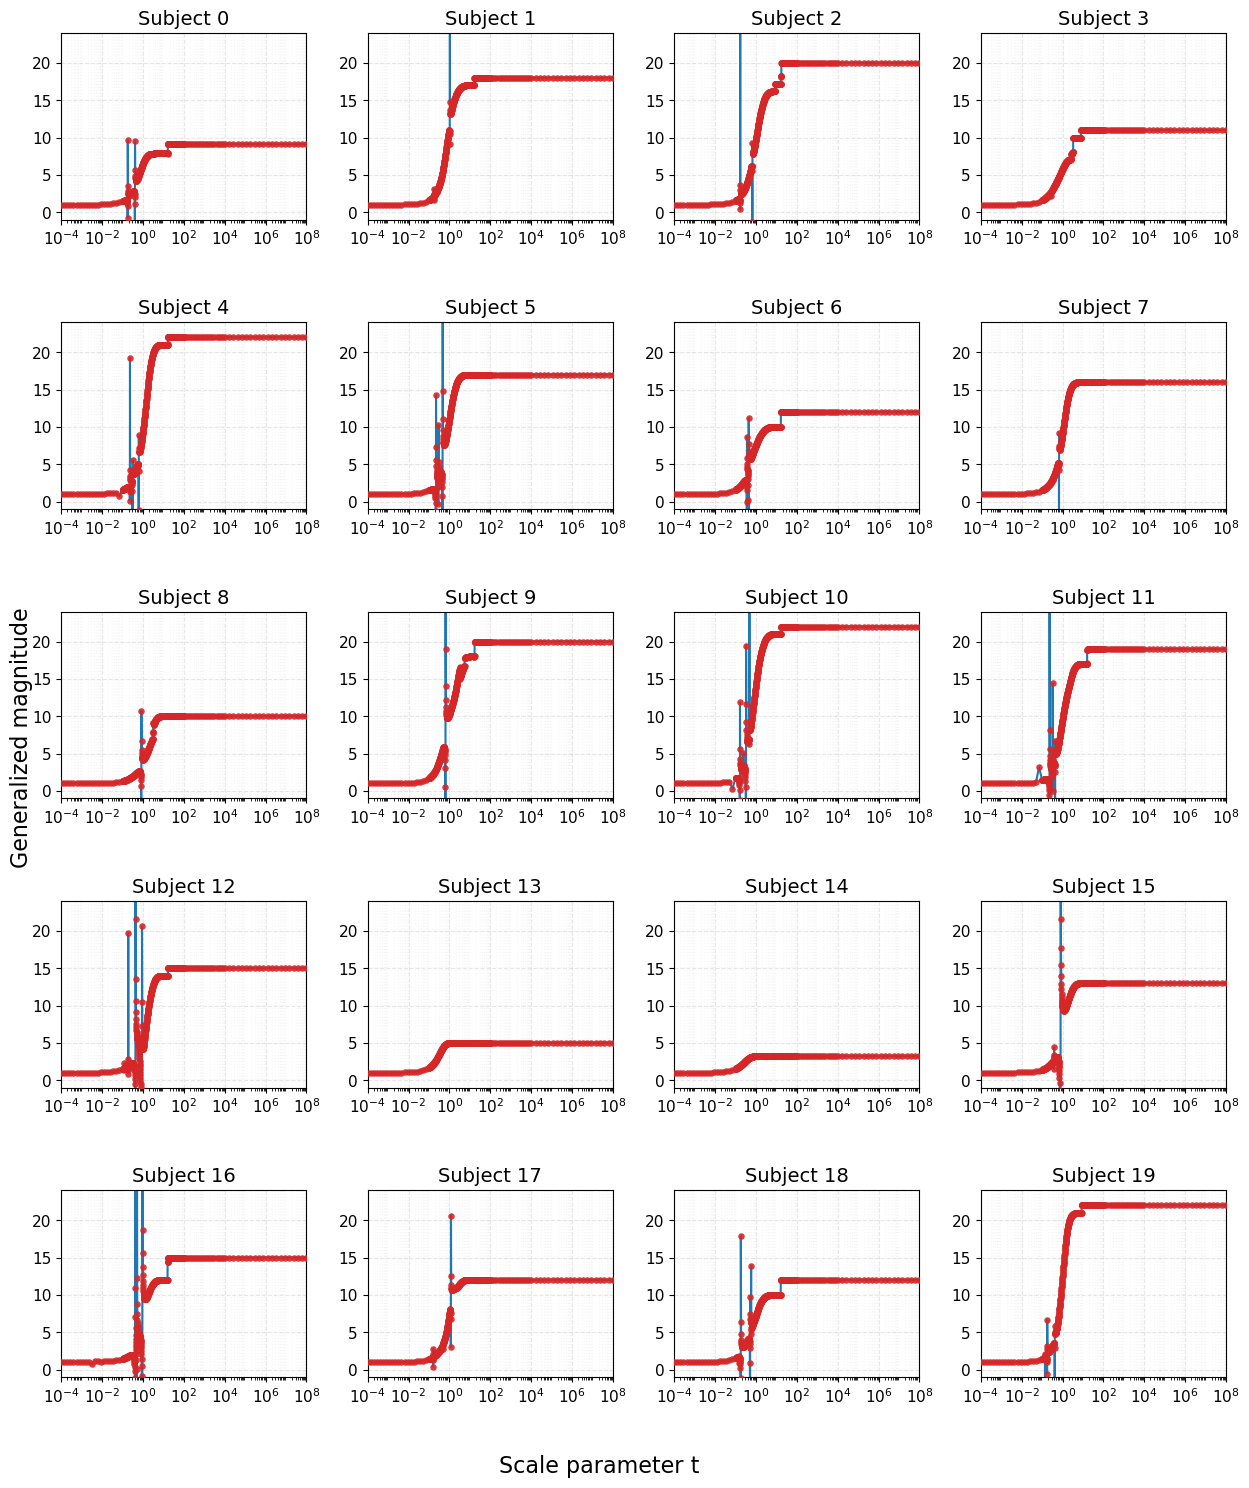

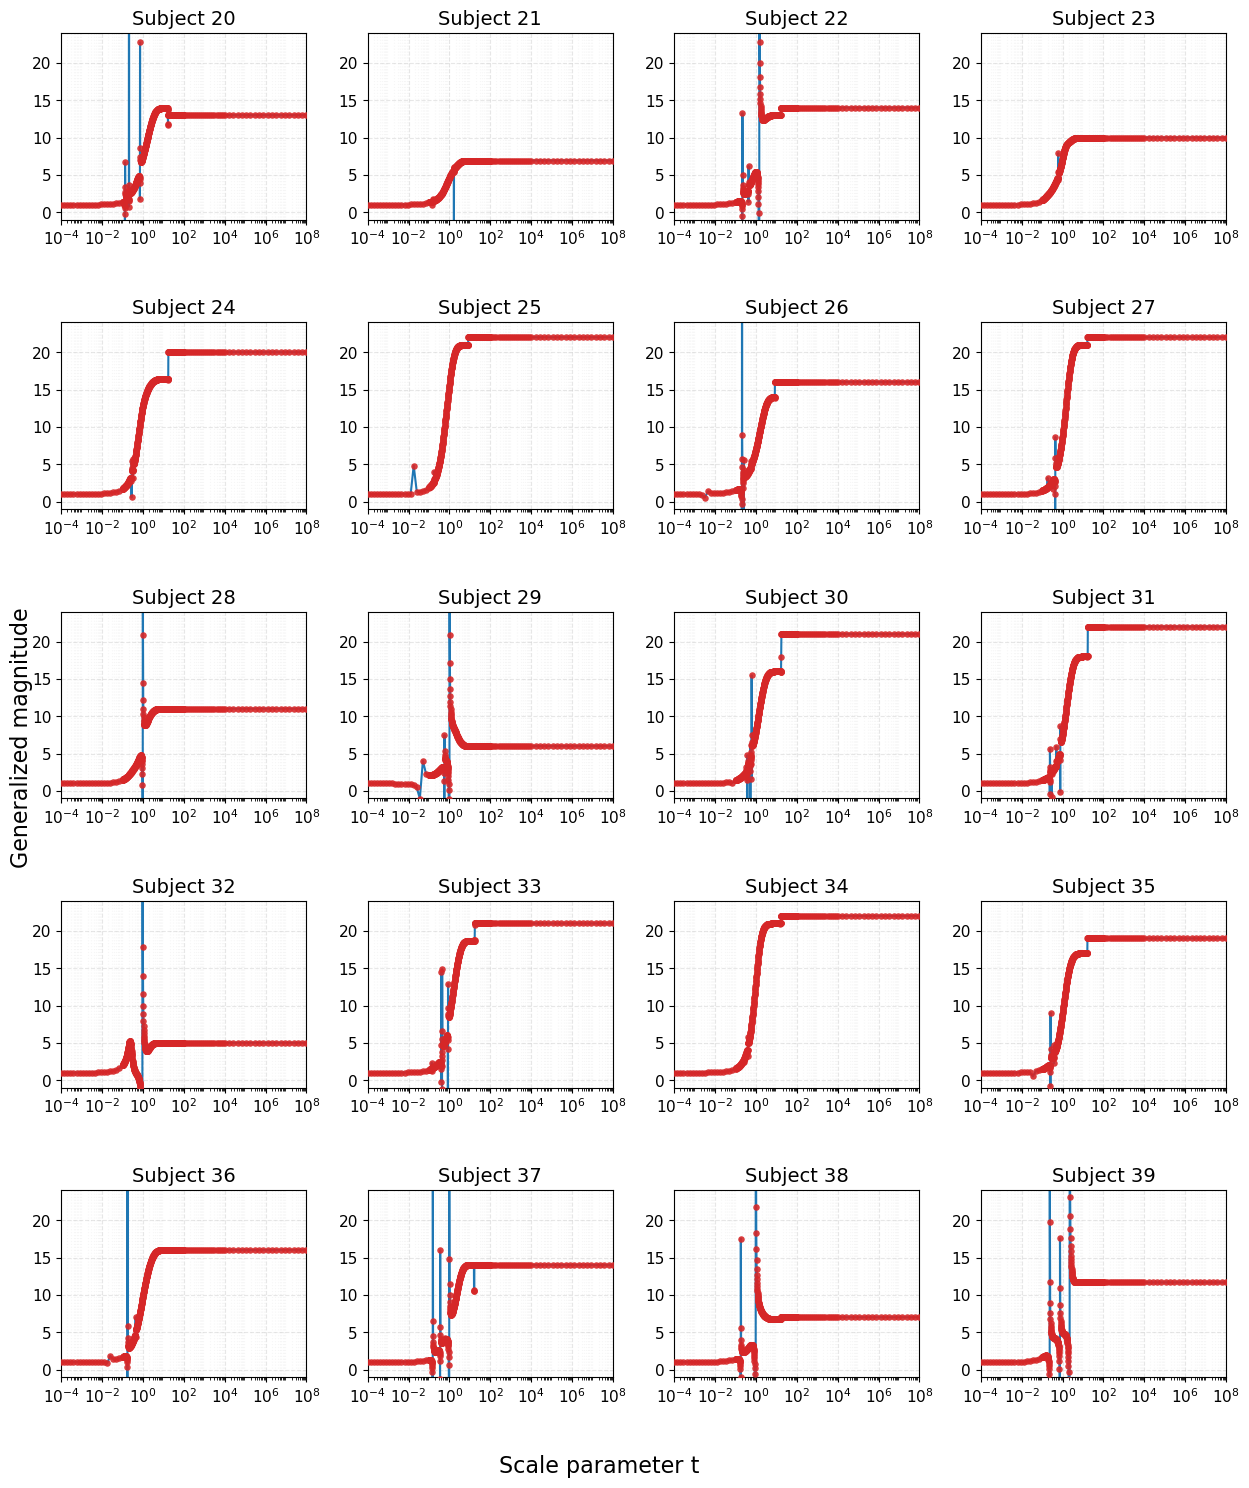

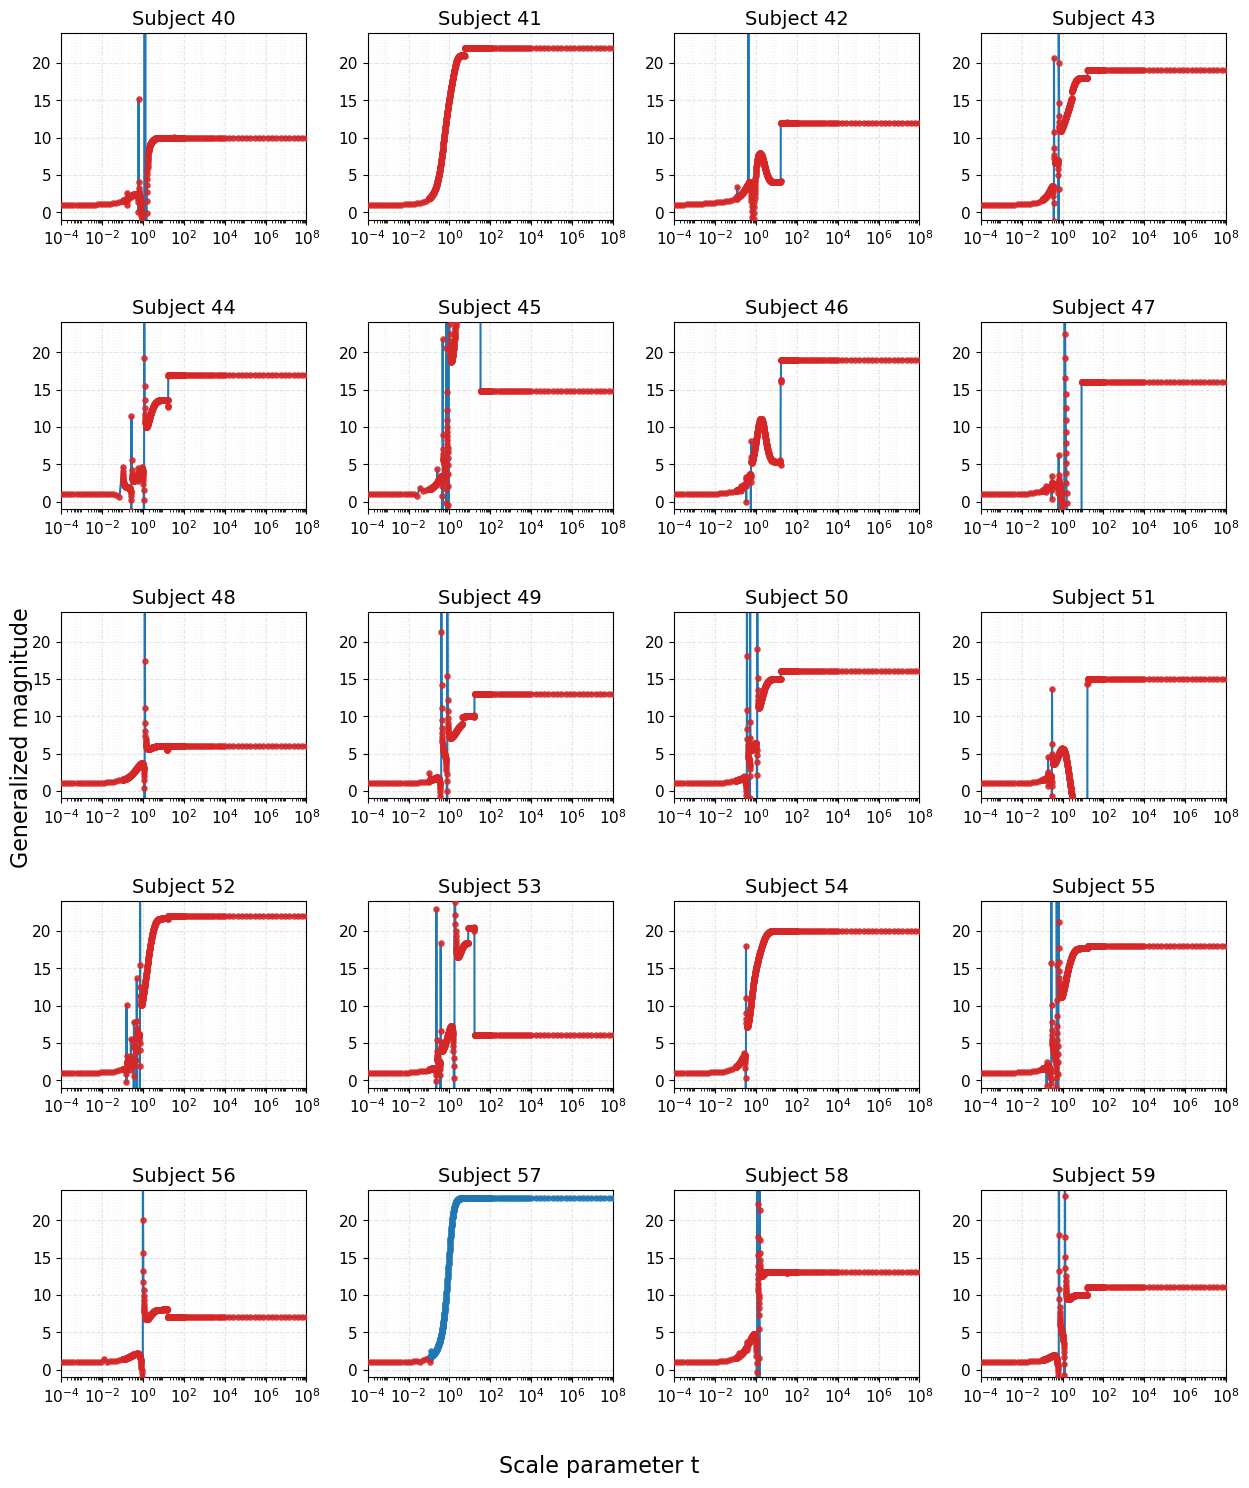

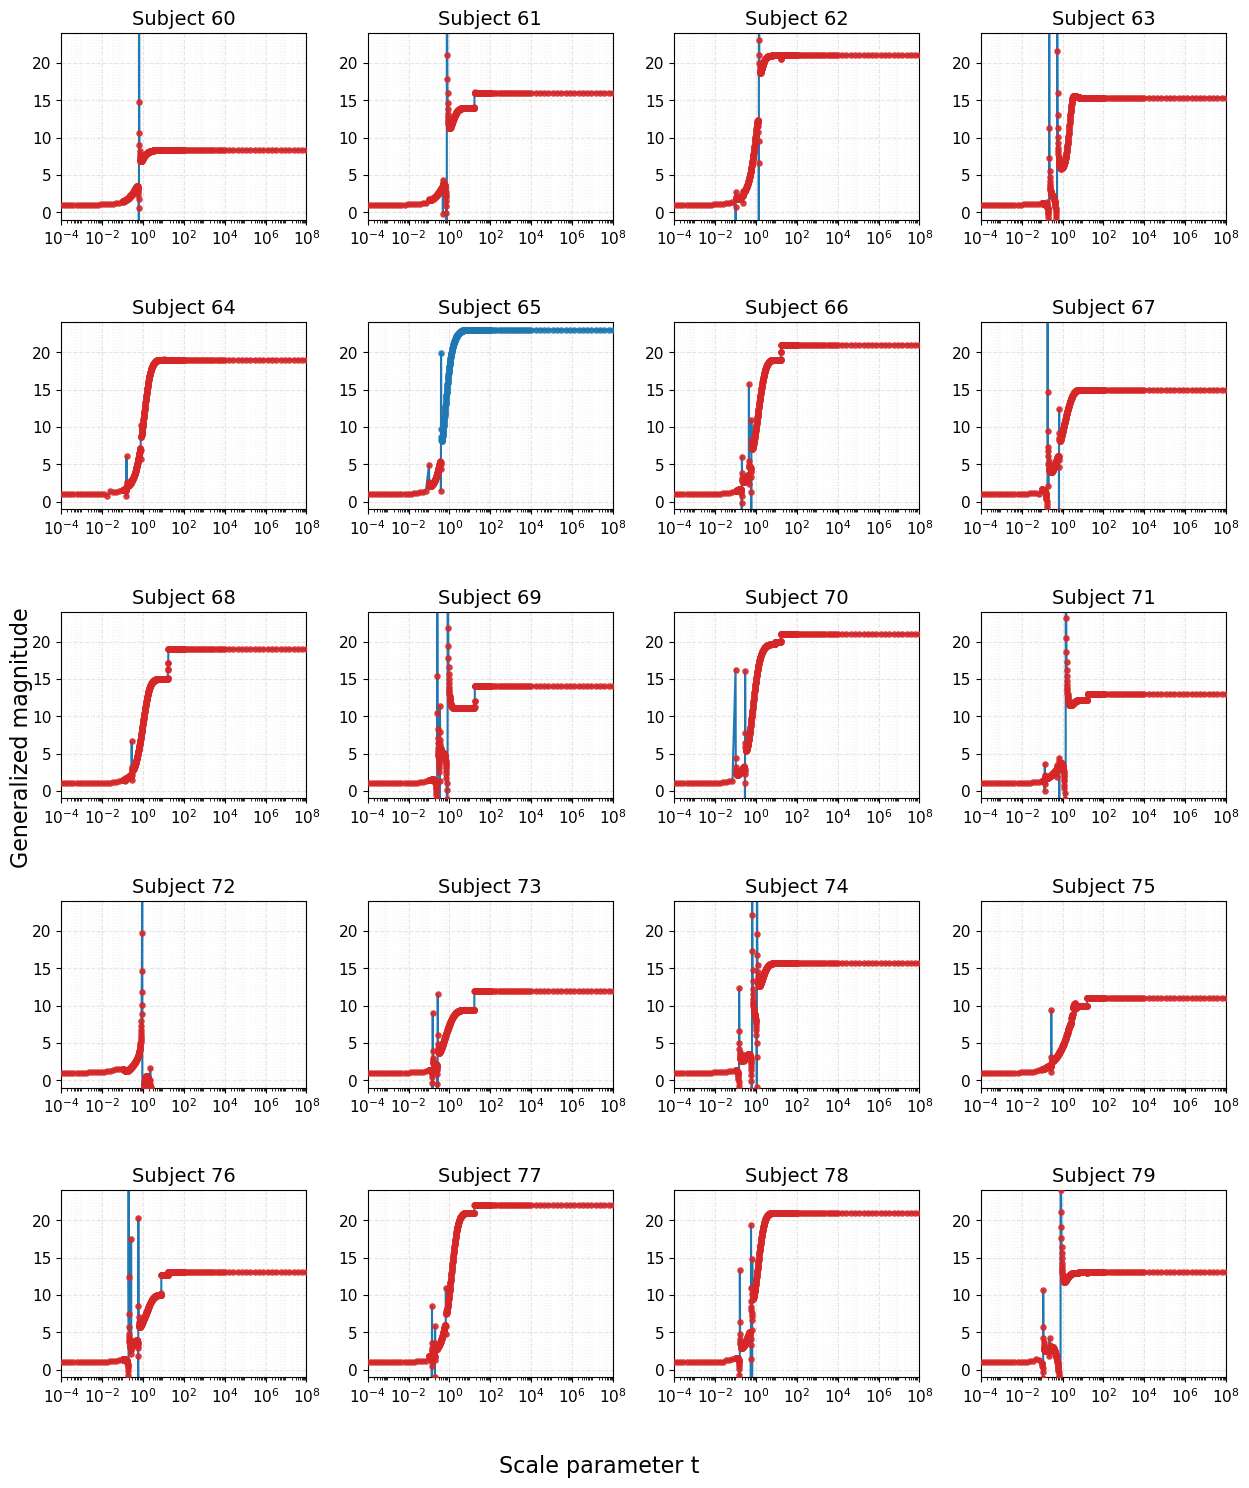

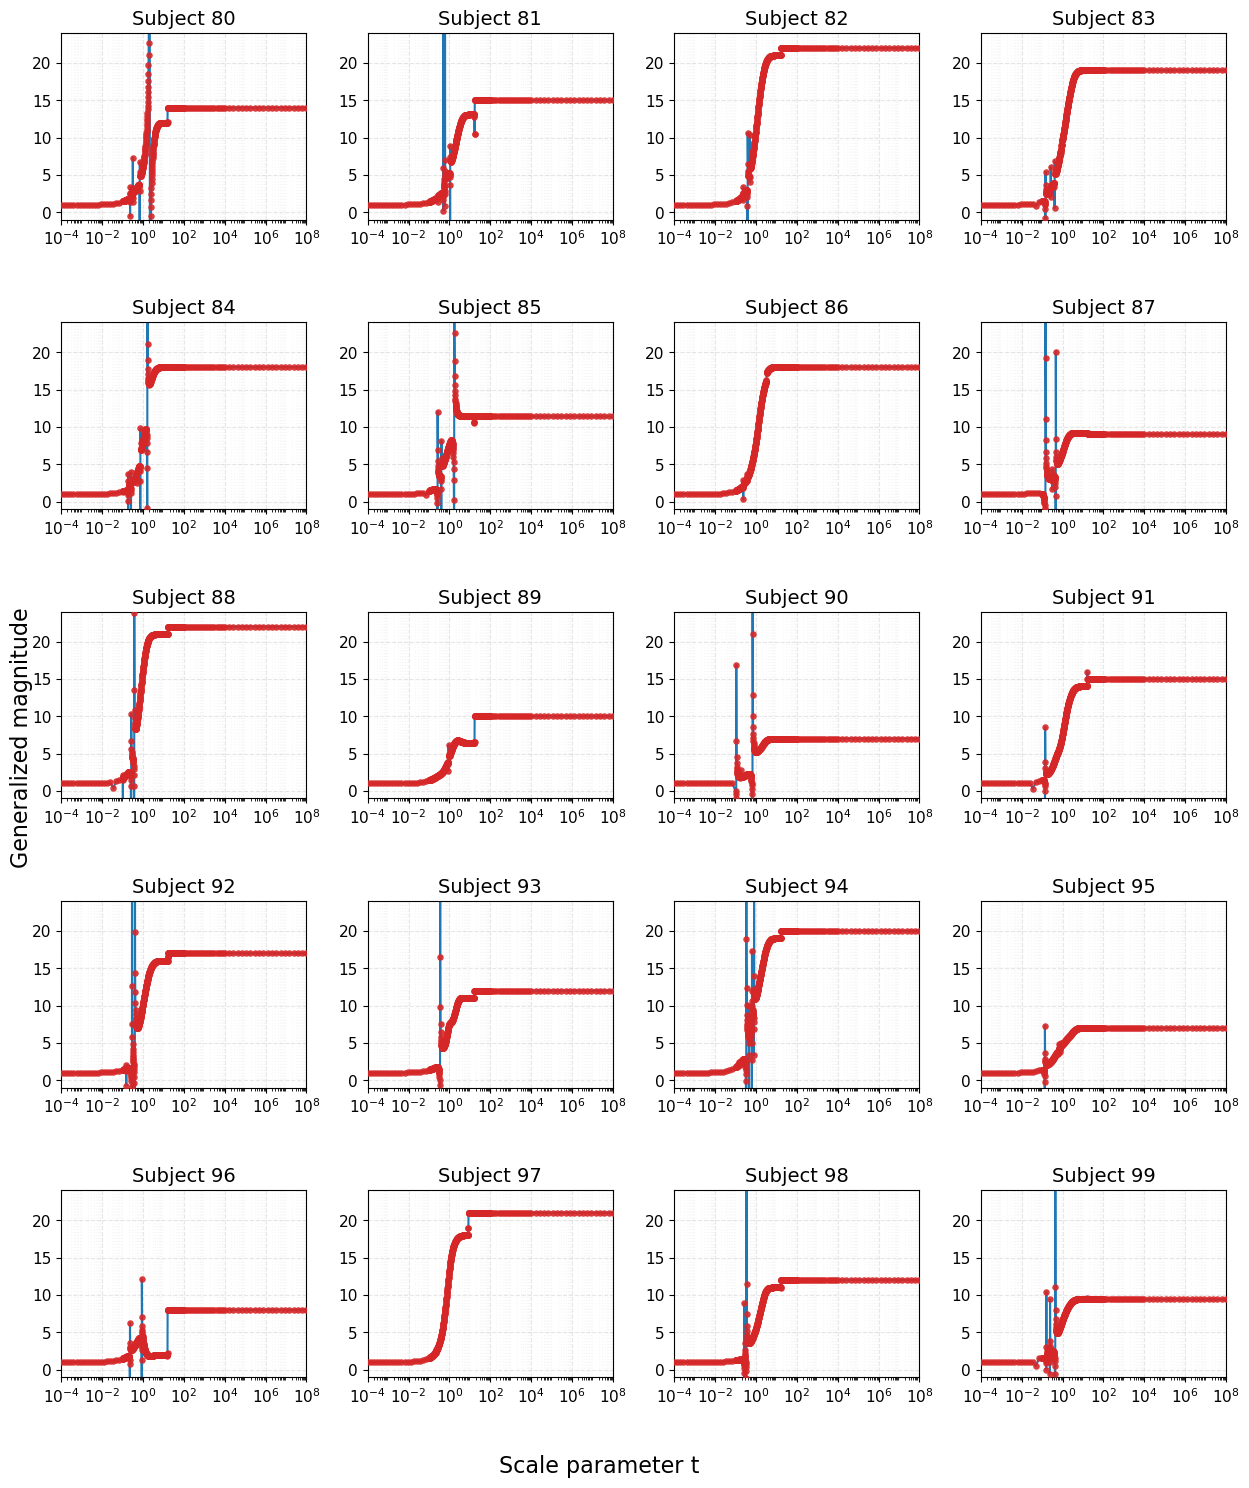

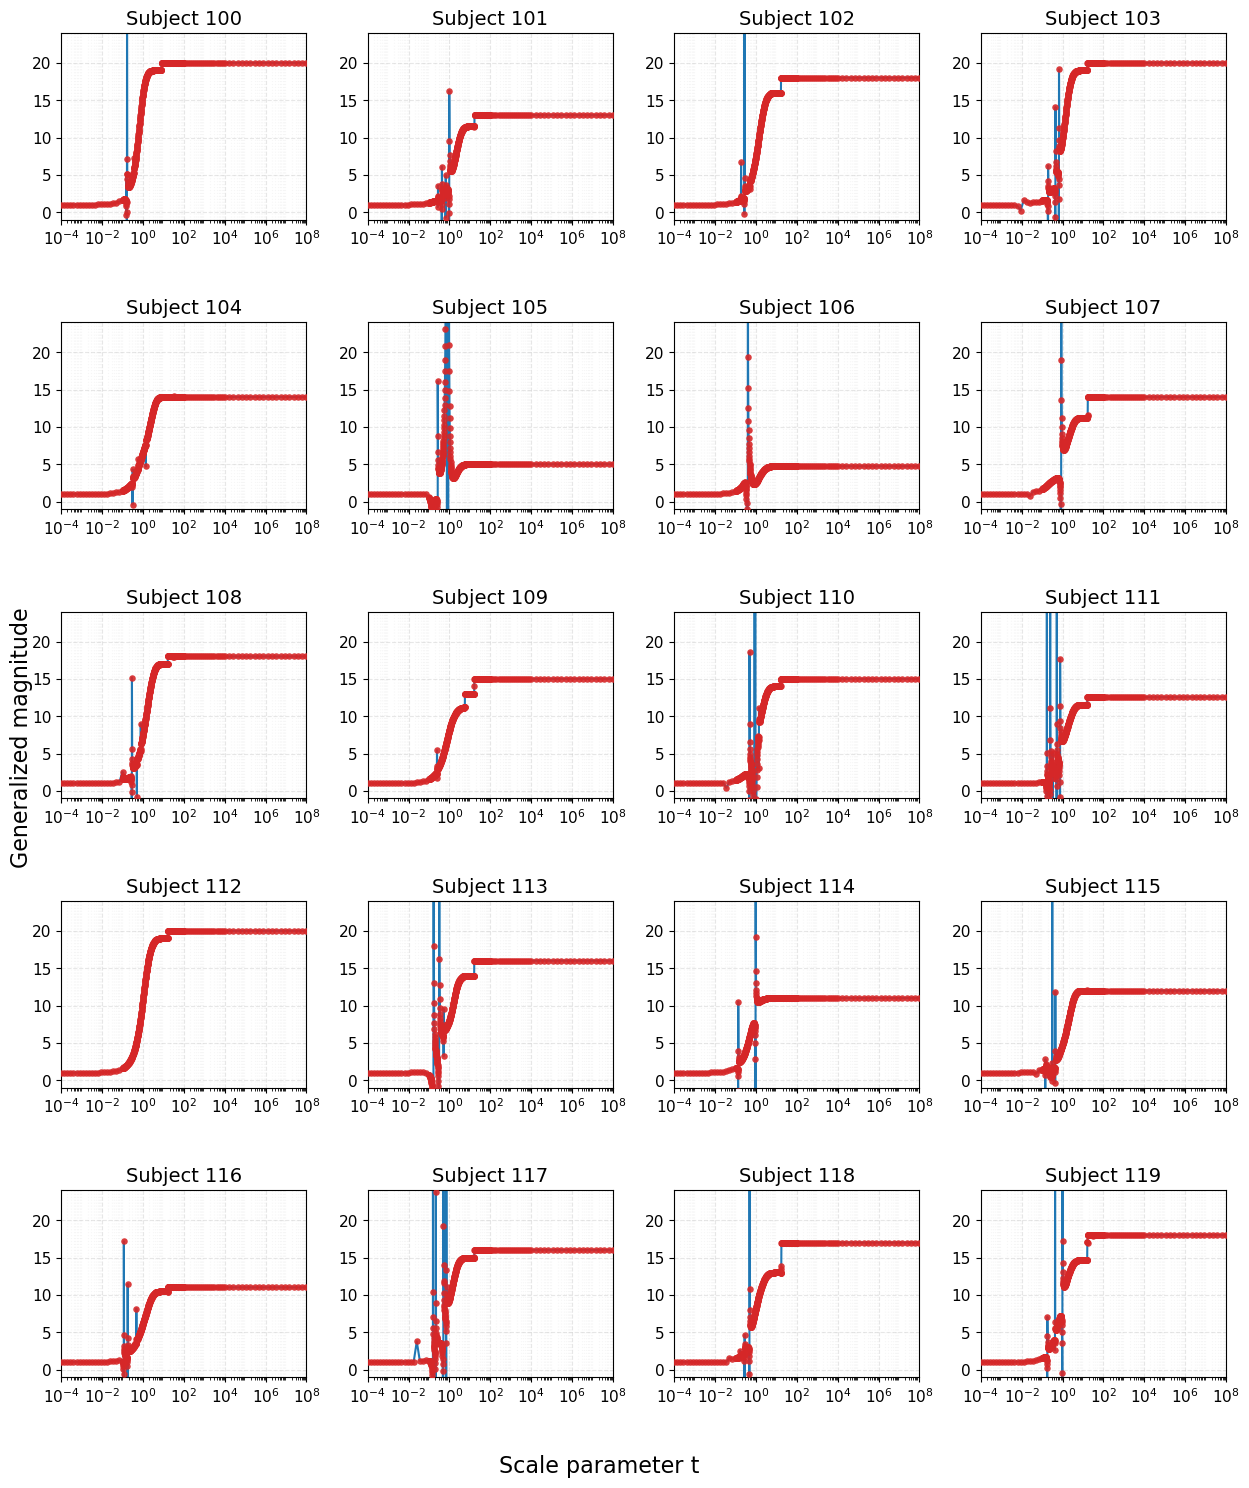

['/home/jovyan/work/fig/temp/Generalized magnitude_page01.png',
 '/home/jovyan/work/fig/temp/Generalized magnitude_page02.png',
 '/home/jovyan/work/fig/temp/Generalized magnitude_page03.png',
 '/home/jovyan/work/fig/temp/Generalized magnitude_page04.png',
 '/home/jovyan/work/fig/temp/Generalized magnitude_page05.png',
 '/home/jovyan/work/fig/temp/Generalized magnitude_page06.png']

In [4]:
output = str(paths.figure("temp"))

viz.plt_metric_individual(
    genmag,
    metric_name="Generalized magnitude",
    output_dir=output,
    nrows=5, ncols=4,
    ylim=[-1, 24], xlim=None,
    xticks_all=True, yticks_all=True,
    positive_definite_df=positive_definite_t_all,
    posdef_mode= "two_color",
)

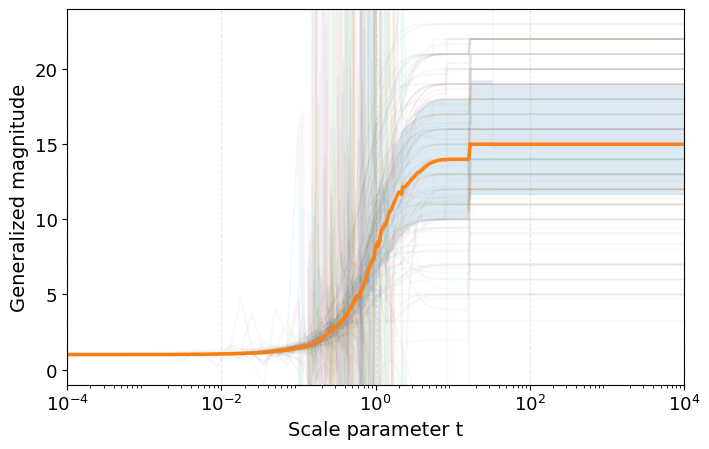

In [3]:
subs = list(range(120))
output = str(paths.figure("group", "wolegend"))
viz.plt_metric_overlay(
    genmag,
    subs,
    "Generalized magnitude",
    None,
    show_aggregate=True,
    aggregate="median",
    show_band=True,
    band_quantiles=(0.25, 0.75),
    show_legend=False,
    xlim=[np.float_power(10, -4), np.power(10, 4)],
    ylim=[-1, 24],
    output_dir=output,
    subject_labels=None,
    alpha=0.05
)

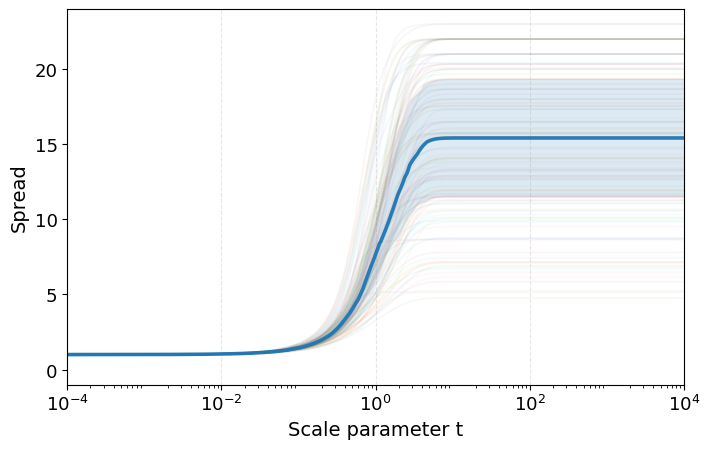

In [3]:
subs = list(range(120))
output = str(paths.figure("group", "wolegend"))
viz.plt_metric_overlay(
    spr,
    subs,
    "Spread",
    None,
    show_aggregate=True,
    aggregate="median",
    show_band=True,
    band_quantiles=(0.25, 0.75),
    show_legend=False,
    xlim=[np.float_power(10, -4), np.power(10, 4)],
    ylim=[-1, 24],
    output_dir=output,
    subject_labels=None,
    alpha=0.05
)

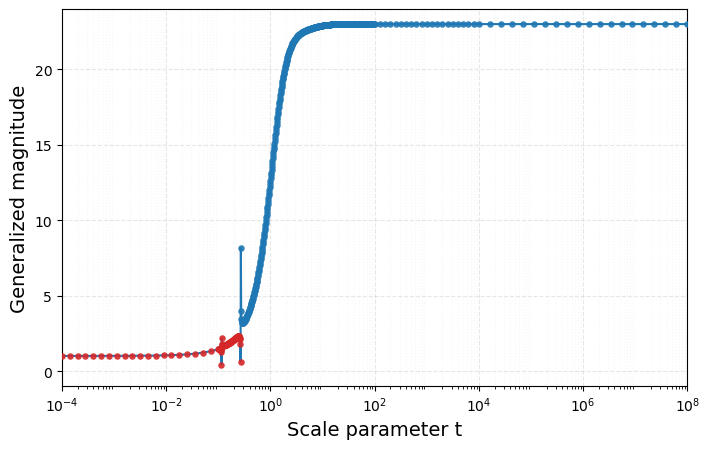

'/home/jovyan/work/fig/temp/Generalized magnitude_sub0.png'

In [7]:
subs = 0
output = str(paths.figure("temp"))

viz.plt_metric_single(
    metric_df=genmag_mean,
    subject=subs,
    metric_name="Generalized magnitude",
    output_dir=output,
    ylim=[-1, 24],
    xlim=None,
    positive_definite_df=positive_definite_t_mean,
    posdef_mode="two_color",
)

In [11]:
ans = core.find_jump_near_target(
    df=genmag,
    subj=30,
    target=19.0,
    band=3,
);

[subj=30] band_y=[16, 22] | candidates: 183
>> Max Jump: x=17.06->17.3, dy=3.062

-- Around Points --
         x         y
16.368165 16.046875
16.595869 15.937500
16.826741 16.078125
17.060824 17.937500
17.298164 20.999999
17.538805 20.999999
17.782794 20.999999
18.030177 21.000000

-- Top Jumps --
  rank    x_left   x_right    y_left   y_right   delta_y  abs_delta_y
    1 17.060824 17.298164 17.937500 20.999999  3.062499     3.062499
    2 16.826741 17.060824 16.078125 17.937500  1.859375     1.859375
    3 16.595869 16.826741 15.937500 16.078125  0.140625     0.140625
    4 16.368165 16.595869 16.046875 15.937500 -0.109375     0.109375
    5 16.143586 16.368165 15.968750 16.046875  0.078125     0.078125
    6 15.703628 15.922087 16.009766 15.980469 -0.029297     0.029297
    7 15.066071 15.275661 15.995117 16.005859  0.010742     0.010742
    8 14.655478 14.859356 16.001953 15.995605 -0.006348     0.006348
    9 14.454398 14.655478 15.999268 16.001953  0.002686     0.002686
   10 15.

In [8]:
genmag.loc[57]

1.000000e-04     1.000470
1.412538e-04     1.000664
1.995262e-04     1.000938
2.818383e-04     1.001325
3.981072e-04     1.001872
                  ...    
1.438450e+07    23.000000
2.335721e+07    23.000000
3.792690e+07    23.000000
6.158482e+07    23.000000
1.000000e+08    23.000000
Name: 57, Length: 560, dtype: float64

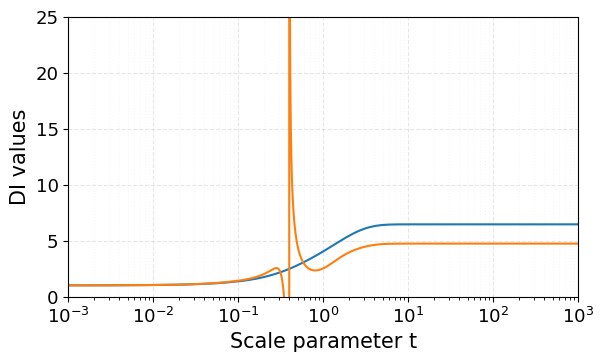

In [30]:
subs = 106
save_path = str(paths.figure("individual", f"{subs}"))
figsize = (6, 3.5)

fig, ax = plt.subplots(figsize=figsize)

t1 = pd.to_numeric(genmag.columns).to_numpy()
t2 = pd.to_numeric(spr.columns).to_numpy()
y1 = genmag.loc[subs].to_numpy()
y2 = spr.loc[subs].to_numpy()


y_lim = [0, 25]
x_lim = (0.001, 1000)

ax.plot(t2, y2)
ax.plot(t1, y1)

_apply_log_x_pretty(ax, x_lim)

ax.set_ylim(*y_lim)
ax.tick_params(axis="x", labelsize=13)
ax.tick_params(axis="y", labelsize=13)
ax.set_xlabel("Scale parameter t", fontsize=15)
ax.set_ylabel("DI values", fontsize=15)
fig.subplots_adjust(left=0.1, right=0.95, bottom=0.15, top=0.95)

fig.savefig(save_path, dpi=300)

In [35]:
genmag.loc[57]

1.000000e-04     1.000470
1.412538e-04     1.000664
1.995262e-04     1.000938
2.818383e-04     1.001325
3.981072e-04     1.001872
                  ...    
1.438450e+07    23.000000
2.335721e+07    23.000000
3.792690e+07    23.000000
6.158482e+07    23.000000
1.000000e+08    23.000000
Name: 57, Length: 560, dtype: float64

In [9]:

def _apply_log_x_pretty(ax: plt.Axes, xlim: tuple[float, float]) -> None:
    ax.set_xscale("log")
    ax.set_xlim(*xlim)

    ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=6))
    ax.xaxis.set_major_formatter(LogFormatterMathtext(base=10.0))

    ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=100))
    ax.xaxis.set_minor_formatter(NullFormatter())

    ax.grid(True, which="major", linestyle="--", alpha=0.3)
    ax.grid(True, which="minor", linestyle=":", alpha=0.1)